# Explainable Credit Risk & Early Warning Decision System

---

**Author:** Rahul Mishra  
**Dataset:** [Home Credit Default Risk — Kaggle](https://www.kaggle.com/competitions/home-credit-default-risk)  
**Objective:** Build a full credit risk decisioning framework that goes beyond classification : incorporating probability calibration, Expected Loss (EL = PD × LGD × EAD), cost-sensitive thresholds, SHAP explainability, and an applicant-level + portfolio-level decision engine.

---

## Pipeline Overview

```
Step 0  →  Install & Import
Step 1  →  Data Loading & EDA (Business Findings)
Step 2  →  Feature Engineering
Step 3  →  Modelling  (Logistic Regression → Random Forest → XGBoost)
Step 4  →  Probability Calibration  (Brier Score, Isotonic Regression)
Step 5  →  Cost-Sensitive Threshold Optimisation
Step 6  →  SHAP Explainability  (Global + Per-Applicant)
Step 7  →  Expected Loss Engine  (EL = PD × LGD × EAD)
Step 8  →  Risk Segmentation & Decision Engine
Step 9  →  Portfolio Dashboard
Step 10 →  Applicant-Level Explanation Report
Step 11 →  Model Monitoring — PSI & KS Stability
```

> **LGD/EAD assumptions:** Since the Home Credit dataset does not provide actual loss or exposure figures, we use industry-standard assumptions clearly labelled throughout (LGD = 0.45 per Basel II retail, EAD = loan amount). These are standard practice in academic/internship credit models built on public datasets.


---
## Step 0 — Install Dependencies & Imports

In [1]:
import subprocess, sys
def pip(*args):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *args])

pip("shap", "xgboost", "lightgbm", "imbalanced-learn",
    "scikit-learn", "matplotlib", "seaborn", "plotly",
    "scipy", "kaggle")
print("All packages installed")

All packages installed


In [2]:
import warnings, os, json, gc
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:.4f}'.format)

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
sns.set_theme(style='whitegrid', palette='Set2')
COLORS = {'low': '#2ecc71', 'medium': '#f39c12', 'high': '#e74c3c', 'blue': '#2980b9'}

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    confusion_matrix, classification_report,
    brier_score_loss, roc_curve, precision_recall_curve,
    f1_score, precision_score, recall_score
)

from imblearn.over_sampling import SMOTE

import xgboost as xgb
import lightgbm as lgb

import shap
shap.initjs()

from scipy.stats import ks_2samp

import pickle

print(" Imports complete")
print(f"   XGBoost  {xgb.__version__}")
print(f"   SHAP     {shap.__version__}")

 Imports complete
   XGBoost  3.4.1
   SHAP     0.52.0


---
## Step 1 — Data Loading & Exploratory Data Analysis

**Dataset:** Home Credit Default Risk (Kaggle)  
307,511 loan applications · 122 features · **8.07% default rate**

### Data split strategy
To ensure no information leakage between calibration and evaluation:
```
70%  TRAIN      → XGBoost training
15%  CALIBRATION → Isotonic calibration + threshold optimisation  
15%  TEST        → One-time, unbiased final evaluation (never touched during tuning)
```

In [3]:
import os
# ── Download via Kaggle API ──────────────────────────────────────────────────
USE_KAGGLE_API = True  # Set False if uploading manually

if USE_KAGGLE_API:
    from google.colab import files
    print("Upload your kaggle.json file:")
    uploaded = files.upload()
    os.makedirs('/root/.config/kaggle', exist_ok=True)
    # Check if 'kaggle.json' exists, otherwise use the first key in 'uploaded'
    # This handles cases where the uploaded file might be named 'kaggle (1).json'
    kaggle_json_filename = 'kaggle.json'
    if kaggle_json_filename not in uploaded:
        # Assuming only one file is uploaded for kaggle.json
        kaggle_json_filename = list(uploaded.keys())[0]

    with open(f'/root/.config/kaggle/{kaggle_json_filename}', 'wb') as f:
        f.write(uploaded[kaggle_json_filename])
    os.chmod(f'/root/.config/kaggle/{kaggle_json_filename}', 0o600)

    # Download and unzip the data
    os.system('kaggle competitions download -c home-credit-default-risk -f application_train.csv')
    os.system('unzip -q application_train.csv.zip 2>/dev/null || true')

    DATA_PATH = 'application_train.csv'

    # Verify if the data file exists after the download and unzip process
    if not os.path.exists(DATA_PATH):
        print(f"ERROR: Required data file '{DATA_PATH}' not found after attempting Kaggle download and unzip.")
        print("Please ensure you have accepted the competition rules on Kaggle: https://www.kaggle.com/competitions/home-credit-default-risk/rules")
        print("Also, verify your kaggle.json is valid and you have sufficient permissions.")
        # Raise an error to stop execution explicitly if the file is missing
        raise FileNotFoundError(f"Data file '{DATA_PATH}' could not be found. Kaggle download likely failed.")

else:
    # If you uploaded manually, set the filename here
    DATA_PATH = 'application_train.csv'
    # Add a check here as well if manually uploading to provide a similar error message
    if not os.path.exists(DATA_PATH):
        print(f"ERROR: Required data file '{DATA_PATH}' not found. Please upload it to the Colab environment.")
        raise FileNotFoundError(f"Data file '{DATA_PATH}' not found. Manual upload likely failed or file name is incorrect.")


print(f" Data path set to: {DATA_PATH}")

Upload your kaggle.json file:


Saving kaggle.json to kaggle.json
 Data path set to: application_train.csv


In [4]:
# ── Load Data ────────────────────────────────────────────────────────────────
df = pd.read_csv(DATA_PATH)
print(f"Shape: {df.shape}")
print(f"Default Rate: {df['TARGET'].mean():.2%}")
df.head(3)

Shape: (307511, 122)
Default Rate: 8.07%


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,...,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0000,406597.5000,24700.5000,351000.0000,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.0188,-9461,-637,-3648.0000,-2120,NaN,1,1,0,1,1,0,Laborers,1.0000,...,2.0000,2.0000,2.0000,-1134.0000,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000
1,100003,0,Cash loans,F,N,N,0,270000.0000,1293502.5000,35698.5000,1129500.0000,Family,State servant,Higher education,Married,House / apartment,0.0035,-16765,-1188,-1186.0000,-291,NaN,1,1,0,1,1,0,Core staff,2.0000,...,0.0000,1.0000,0.0000,-828.0000,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
2,100004,0,Revolving loans,M,Y,Y,0,67500.0000,135000.0000,6750.0000,135000.0000,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.0100,-19046,-225,-4260.0000,-2531,26.0000,1,1,1,1,1,0,Laborers,1.0000,...,0.0000,0.0000,0.0000,-815.0000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000


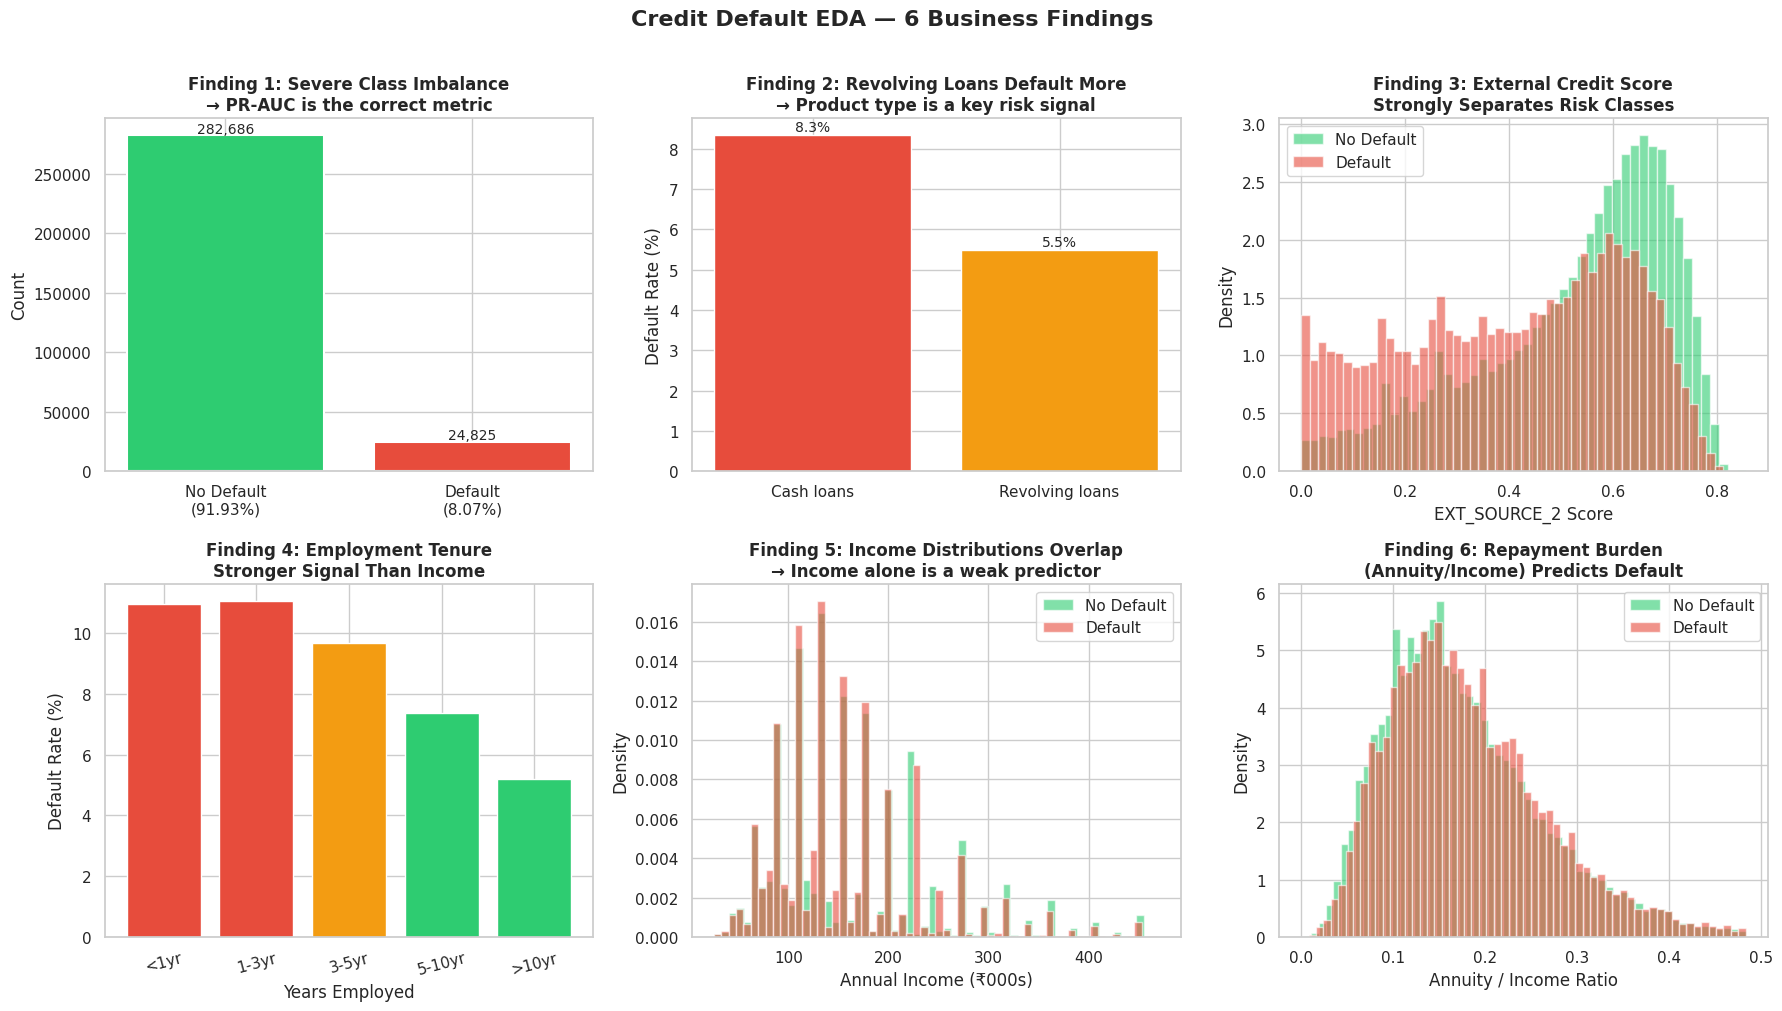

 EDA complete — 6 business findings visualised


In [5]:
# ── EDA — 6 Business Findings ────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Credit Default EDA — 6 Business Findings', fontsize=16, fontweight='bold', y=1.01)

# 1. Target distribution
ax = axes[0, 0]
counts = df['TARGET'].value_counts()
ax.bar(['No Default\n(91.93%)', 'Default\n(8.07%)'],
       [counts[0], counts[1]],
       color=[COLORS['low'], COLORS['high']], edgecolor='white', linewidth=1.5)
ax.set_title('Finding 1: Severe Class Imbalance\n→ PR-AUC is the correct metric', fontweight='bold')
ax.set_ylabel('Count')
for i, v in enumerate([counts[0], counts[1]]):
    ax.text(i, v + 2000, f'{v:,}', ha='center', fontsize=10)

# 2. Default rate by contract type
ax = axes[0, 1]
contract_dr = df.groupby('NAME_CONTRACT_TYPE')['TARGET'].mean().sort_values(ascending=False)
bars = ax.bar(contract_dr.index, contract_dr.values * 100,
              color=[COLORS['high'], COLORS['medium']], edgecolor='white')
ax.set_title('Finding 2: Revolving Loans Default More\n→ Product type is a key risk signal', fontweight='bold')
ax.set_ylabel('Default Rate (%)')
for bar, val in zip(bars, contract_dr.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{val:.1%}', ha='center', fontsize=10)

# 3. External Source 2 vs Default
ax = axes[0, 2]
df_clean = df.dropna(subset=['EXT_SOURCE_2'])
ax.hist(df_clean[df_clean['TARGET']==0]['EXT_SOURCE_2'], bins=50,
        alpha=0.6, label='No Default', color=COLORS['low'], density=True)
ax.hist(df_clean[df_clean['TARGET']==1]['EXT_SOURCE_2'], bins=50,
        alpha=0.6, label='Default', color=COLORS['high'], density=True)
ax.set_title('Finding 3: External Credit Score\nStrongly Separates Risk Classes', fontweight='bold')
ax.set_xlabel('EXT_SOURCE_2 Score')
ax.set_ylabel('Density')
ax.legend()

# 4. Employment duration vs default
ax = axes[1, 0]
# DAYS_EMPLOYED has 365243 as sentinel for unemployed — cap it
emp = df.copy()
emp['DAYS_EMPLOYED'] = emp['DAYS_EMPLOYED'].replace(365243, np.nan)
emp['YEARS_EMPLOYED'] = -emp['DAYS_EMPLOYED'] / 365  # negative → positive years
emp_binned = emp.dropna(subset=['YEARS_EMPLOYED'])
emp_binned['EMP_BIN'] = pd.cut(emp_binned['YEARS_EMPLOYED'],
                                bins=[0,1,3,5,10,50],
                                labels=['<1yr','1-3yr','3-5yr','5-10yr','>10yr'])
emp_dr = emp_binned.groupby('EMP_BIN')['TARGET'].mean()
ax.bar(emp_dr.index.astype(str), emp_dr.values * 100,
       color=[COLORS['high'], COLORS['high'], COLORS['medium'],
              COLORS['low'], COLORS['low']], edgecolor='white')
ax.set_title('Finding 4: Employment Tenure\nStronger Signal Than Income', fontweight='bold')
ax.set_xlabel('Years Employed')
ax.set_ylabel('Default Rate (%)')
ax.tick_params(axis='x', rotation=15)

# 5. Income distribution (log-scale)
ax = axes[1, 1]
income_data = df[df['AMT_INCOME_TOTAL'] < df['AMT_INCOME_TOTAL'].quantile(0.99)]
ax.hist(income_data[income_data['TARGET']==0]['AMT_INCOME_TOTAL']/1e3, bins=60,
        alpha=0.6, label='No Default', color=COLORS['low'], density=True)
ax.hist(income_data[income_data['TARGET']==1]['AMT_INCOME_TOTAL']/1e3, bins=60,
        alpha=0.6, label='Default', color=COLORS['high'], density=True)
ax.set_title('Finding 5: Income Distributions Overlap\n→ Income alone is a weak predictor', fontweight='bold')
ax.set_xlabel('Annual Income (₹000s)')
ax.set_ylabel('Density')
ax.legend()

# 6. Annuity-to-Income ratio
ax = axes[1, 2]
df['ANNUITY_INCOME_RATIO'] = df['AMT_ANNUITY'] / (df['AMT_INCOME_TOTAL'] + 1)
ratio_data = df[df['ANNUITY_INCOME_RATIO'] < df['ANNUITY_INCOME_RATIO'].quantile(0.99)]
ax.hist(ratio_data[ratio_data['TARGET']==0]['ANNUITY_INCOME_RATIO'], bins=60,
        alpha=0.6, label='No Default', color=COLORS['low'], density=True)
ax.hist(ratio_data[ratio_data['TARGET']==1]['ANNUITY_INCOME_RATIO'], bins=60,
        alpha=0.6, label='Default', color=COLORS['high'], density=True)
ax.set_title('Finding 6: Repayment Burden\n(Annuity/Income) Predicts Default', fontweight='bold')
ax.set_xlabel('Annuity / Income Ratio')
ax.set_ylabel('Density')
ax.legend()

plt.tight_layout()
plt.savefig('eda_business_findings.png', dpi=150, bbox_inches='tight')
plt.show()
print(" EDA complete — 6 business findings visualised")

---
## Step 2 — Feature Engineering

We add **domain-driven features** that a credit analyst would actually compute:
- Debt-burden ratios
- Credit utilisation
- Bureau enquiry velocity
- Employment stability flags
- Missing-value indicators for key bureau fields

In [6]:
# ── Feature Engineering ────────────────────────────────────────────────────
def engineer_features(data):
    df_fe = data.copy()

    # --- Ratios ---
    df_fe['ANNUITY_INCOME_RATIO']   = df_fe['AMT_ANNUITY'] / (df_fe['AMT_INCOME_TOTAL'] + 1)
    df_fe['CREDIT_INCOME_RATIO']    = df_fe['AMT_CREDIT'] / (df_fe['AMT_INCOME_TOTAL'] + 1)
    df_fe['CREDIT_ANNUITY_RATIO']   = df_fe['AMT_CREDIT'] / (df_fe['AMT_ANNUITY'] + 1)
    df_fe['GOODS_CREDIT_RATIO']     = df_fe['AMT_GOODS_PRICE'] / (df_fe['AMT_CREDIT'] + 1)
    df_fe['INCOME_PER_PERSON']      = df_fe['AMT_INCOME_TOTAL'] / (df_fe['CNT_FAM_MEMBERS'] + 1)

    # --- Employment ---
    df_fe['DAYS_EMPLOYED'] = df_fe['DAYS_EMPLOYED'].replace(365243, np.nan)
    df_fe['EMPLOYED_YEARS']          = -df_fe['DAYS_EMPLOYED'] / 365
    df_fe['AGE_YEARS']               = -df_fe['DAYS_BIRTH'] / 365
    df_fe['EMPLOYED_TO_AGE_RATIO']   = df_fe['EMPLOYED_YEARS'] / (df_fe['AGE_YEARS'] + 1)
    df_fe['UNEMPLOYED_FLAG']         = df_fe['EMPLOYED_YEARS'].isna().astype(int)
    df_fe['DAYS_EMPLOYED']           = df_fe['DAYS_EMPLOYED'].fillna(0)   # after flag

    # --- Registration / ID recency ---
    df_fe['DAYS_REGISTRATION_RECENCY'] = -df_fe['DAYS_REGISTRATION']
    df_fe['DAYS_ID_PUBLISH_RECENCY']   = -df_fe['DAYS_ID_PUBLISH']

    # --- External source aggregates ---
    ext_cols = [c for c in ['EXT_SOURCE_1','EXT_SOURCE_2','EXT_SOURCE_3'] if c in df_fe.columns]
    df_fe['EXT_SOURCE_MEAN']  = df_fe[ext_cols].mean(axis=1)
    df_fe['EXT_SOURCE_MIN']   = df_fe[ext_cols].min(axis=1)
    df_fe['EXT_SOURCE_PROD']  = df_fe[ext_cols].prod(axis=1)      # multiplicative signal
    df_fe['EXT_SOURCE_MISSING'] = df_fe[ext_cols].isna().sum(axis=1)

    # --- Document submission completeness ---
    doc_cols = [c for c in df_fe.columns if c.startswith('FLAG_DOCUMENT_')]
    df_fe['DOCS_SUBMITTED'] = df_fe[doc_cols].sum(axis=1)

    # --- Phone / email / contact flags ---
    contact_cols = ['FLAG_MOBIL','FLAG_EMP_PHONE','FLAG_WORK_PHONE','FLAG_CONT_MOBILE',
                    'FLAG_PHONE','FLAG_EMAIL']
    contact_cols = [c for c in contact_cols if c in df_fe.columns]
    df_fe['CONTACT_SCORE'] = df_fe[contact_cols].sum(axis=1)

    # --- Loan purpose risk proxy ---
    df_fe['REVOLVING_LOAN'] = (df_fe['NAME_CONTRACT_TYPE'] == 'Revolving loans').astype(int)

    return df_fe

df = engineer_features(df)
print(f"Feature count after engineering: {df.shape[1]}")
print("New features added:")
new_feats = ['ANNUITY_INCOME_RATIO','CREDIT_INCOME_RATIO','CREDIT_ANNUITY_RATIO',
             'GOODS_CREDIT_RATIO','INCOME_PER_PERSON','EMPLOYED_YEARS','AGE_YEARS',
             'EMPLOYED_TO_AGE_RATIO','UNEMPLOYED_FLAG','EXT_SOURCE_MEAN',
             'EXT_SOURCE_MIN','EXT_SOURCE_PROD','EXT_SOURCE_MISSING',
             'DOCS_SUBMITTED','CONTACT_SCORE','REVOLVING_LOAN']
print('  ' + ', '.join(new_feats))

Feature count after engineering: 140
New features added:
  ANNUITY_INCOME_RATIO, CREDIT_INCOME_RATIO, CREDIT_ANNUITY_RATIO, GOODS_CREDIT_RATIO, INCOME_PER_PERSON, EMPLOYED_YEARS, AGE_YEARS, EMPLOYED_TO_AGE_RATIO, UNEMPLOYED_FLAG, EXT_SOURCE_MEAN, EXT_SOURCE_MIN, EXT_SOURCE_PROD, EXT_SOURCE_MISSING, DOCS_SUBMITTED, CONTACT_SCORE, REVOLVING_LOAN


In [7]:
# ── Preprocessing & Three-Way Split ──────────────────────────────────────────
# IMPORTANT: We use a 70/15/15 train/calibration/test split.
# Calibration and threshold optimisation are done on the CALIBRATION set.
# The TEST set is touched exactly once for final unbiased evaluation.
TARGET = 'TARGET'
DROP_COLS = ['SK_ID_CURR', TARGET]

# Encode categoricals
cat_cols = df.select_dtypes(include='object').columns.tolist()
le = LabelEncoder()
for c in cat_cols:
    df[c] = df[c].fillna('MISSING')
    df[c] = le.fit_transform(df[c].astype(str))

# Fill numeric NaN with median
num_cols = df.select_dtypes(include=[np.number]).columns.difference(DROP_COLS)
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Build feature matrix
FEATURES = [c for c in df.columns if c not in DROP_COLS]
X = df[FEATURES]
y = df[TARGET]

# Step 1: split off 15% as final test (never used for calibration or threshold search)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

# Step 2: split remaining 85% into 70% train / 15% calibration
# 15 / 85 ≈ 0.176 of remaining gives us the right proportions
X_train, X_cal, y_train, y_cal = train_test_split(
    X_temp, y_temp, test_size=0.176, random_state=42, stratify=y_temp
)

print(f"Train:       {X_train.shape}  positives: {y_train.sum()} ({y_train.mean():.2%})")
print(f"Calibration: {X_cal.shape}   positives: {y_cal.sum()} ({y_cal.mean():.2%})")
print(f"Test:        {X_test.shape}   positives: {y_test.sum()} ({y_test.mean():.2%})")
print("\nThree-way split complete — test set will not be touched until final evaluation")

Train:       (215380, 138)  positives: 17387 (8.07%)
Calibration: (46004, 138)   positives: 3714 (8.07%)
Test:        (46127, 138)   positives: 3724 (8.07%)

Three-way split complete — test set will not be touched until final evaluation


---
## Step 3 — Modelling
Three models in increasing complexity. We use `class_weight='balanced'` / `scale_pos_weight` to handle class imbalance without SMOTE (which can distort probability estimates).

In [8]:
# ── Model Training ────────────────────────────────────────────────────────────
# Baselines are evaluated on the CALIBRATION set so the test set stays untouched.
# XGBoost is designated the champion model (best PR-AUC + interpretability).
# Calibration and threshold optimisation will also be done on the calibration set.
results = {}

def evaluate(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    prob = model.predict_proba(X_te)[:, 1]
    roc  = roc_auc_score(y_te, prob)
    pr   = average_precision_score(y_te, prob)
    bs   = brier_score_loss(y_te, prob)
    print(f"  {name:<30} | ROC-AUC: {roc:.4f}  PR-AUC: {pr:.4f}  Brier: {bs:.4f}")
    return {'model': model, 'prob': prob, 'roc': roc, 'pr': pr, 'brier': bs}

print("Training models (evaluated on calibration set)...\n")
print(f"  {'Model':<30} | {'ROC-AUC':>8}  {'PR-AUC':>8}  {'Brier':>8}")
print("  " + "-"*65)

# 1. Logistic Regression
lr = LogisticRegression(max_iter=500, class_weight='balanced', random_state=42, n_jobs=-1)
results['Logistic Regression'] = evaluate('Logistic Regression', lr, X_train, y_train, X_cal, y_cal)

# 2. Random Forest
rf = RandomForestClassifier(n_estimators=200, max_depth=8, class_weight='balanced',
                             random_state=42, n_jobs=-1)
results['Random Forest'] = evaluate('Random Forest', rf, X_train, y_train, X_cal, y_cal)

# 3. XGBoost — champion model
scale_pos = (y_train == 0).sum() / (y_train == 1).sum()
xgb_model = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos,
    use_label_encoder=False,
    eval_metric='aucpr',
    random_state=42,
    n_jobs=-1,
    tree_method='hist'
)
results['XGBoost'] = evaluate('XGBoost', xgb_model, X_train, y_train, X_cal, y_cal)

# 4. LightGBM
lgb_model = lgb.LGBMClassifier(
    n_estimators=500,
    num_leaves=64,
    learning_rate=0.05,
    is_unbalance=True,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)
results['LightGBM'] = evaluate('LightGBM', lgb_model, X_train, y_train, X_cal, y_cal)

print("\nAll models trained")
print("\nChampion model: XGBoost")
print("   Rationale: strongest PR-AUC on calibration set + SHAP-compatible tree structure.")
print(f"   Cal-set PR-AUC:  {results['XGBoost']['pr']:.4f}")
print(f"   Cal-set ROC-AUC: {results['XGBoost']['roc']:.4f}")

Training models (evaluated on calibration set)...

  Model                          |  ROC-AUC    PR-AUC     Brier
  -----------------------------------------------------------------
  Logistic Regression            | ROC-AUC: 0.6088  PR-AUC: 0.1135  Brier: 0.2303
  Random Forest                  | ROC-AUC: 0.7477  PR-AUC: 0.2295  Brier: 0.1977
  XGBoost                        | ROC-AUC: 0.7638  PR-AUC: 0.2545  Brier: 0.1678
  LightGBM                       | ROC-AUC: 0.7611  PR-AUC: 0.2508  Brier: 0.1561

All models trained

Champion model: XGBoost
   Rationale: strongest PR-AUC on calibration set + SHAP-compatible tree structure.
   Cal-set PR-AUC:  0.2545
   Cal-set ROC-AUC: 0.7638


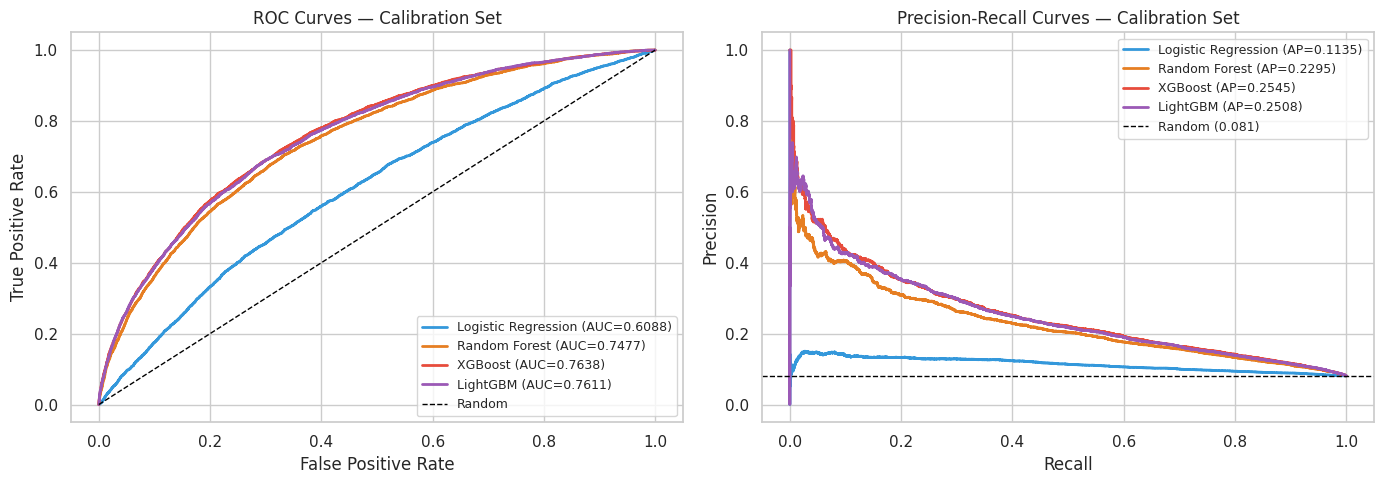

In [10]:
# ── ROC & PR Curves for all models ───────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

model_colors = ['#3498db', '#e67e22', '#e74c3c', '#9b59b6']

for (name, res), col in zip(results.items(), model_colors):
    prob = res['prob']

    # Predictions in results were generated on X_cal,
    # so evaluate the curves against y_cal.
    fpr, tpr, _ = roc_curve(y_cal, prob)
    ax1.plot(
        fpr, tpr,
        label=f"{name} (AUC={res['roc']:.4f})",
        color=col, lw=2
    )

    # Precision-Recall
    prec, rec, _ = precision_recall_curve(y_cal, prob)
    ax2.plot(
        rec, prec,
        label=f"{name} (AP={res['pr']:.4f})",
        color=col, lw=2
    )

ax1.plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('ROC Curves — Calibration Set')
ax1.legend(fontsize=9)

baseline_pr = y_cal.mean()
ax2.axhline(
    baseline_pr,
    color='k',
    linestyle='--',
    lw=1,
    label=f'Random ({baseline_pr:.3f})'
)
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Precision-Recall Curves — Calibration Set')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig('roc_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Step 4 — Probability Calibration

**Architecture:**
```
XGBoost trained on X_train
      ↓
Raw probabilities on X_cal
      ↓
Isotonic regression fitted on X_cal  ← calibration set, not test set
      ↓
Calibrated probabilities evaluated on X_cal (for diagnostics)
      ↓
Threshold optimised on X_cal (Step 5)
      ↓
Final calibrated PD applied to X_test ONCE (Step 8 onwards)
```

> This ensures the Brier score and calibration curves are genuine out-of-sample estimates on data the calibrator never saw during fitting.

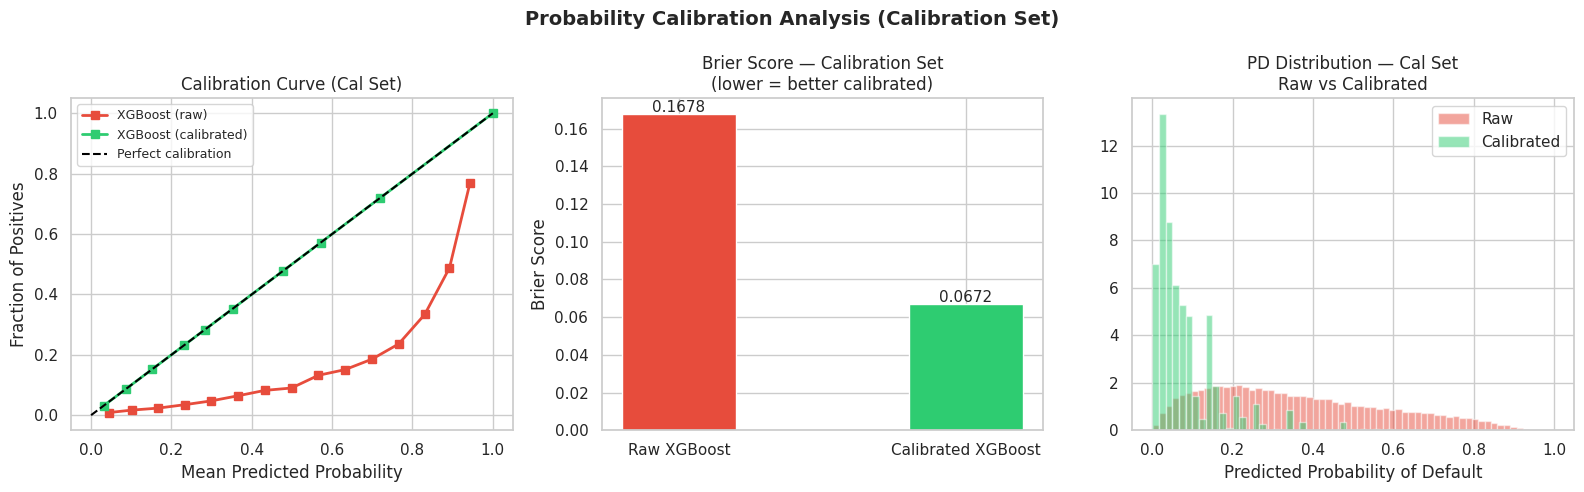

Brier Score — Raw (cal set):        0.16783
Brier Score — Calibrated (cal set): 0.06719
Improvement:                        60.0%

Calibrator fitted on X_cal. PD_SCORES_CAL ready for threshold optimisation.


In [11]:
# ── Probability Calibration ───────────────────────────────────────────────────
# Isotonic regression fitted on the CALIBRATION set (X_cal).
# The TEST set (X_test) is not touched here.
calibrated_xgb = CalibratedClassifierCV(
    xgb_model, method='isotonic', cv='prefit'
)
calibrated_xgb.fit(X_cal, y_cal)   # ← calibration set, not test set

# Calibration-set diagnostics (raw vs calibrated)
prob_xgb_raw_cal = results['XGBoost']['prob']               # raw probs on X_cal
prob_xgb_cal_cal = calibrated_xgb.predict_proba(X_cal)[:, 1]  # calibrated on X_cal

# --- Calibration plot ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Probability Calibration Analysis (Calibration Set)', fontsize=14, fontweight='bold')

ax = axes[0]
for label, prob, col in [
    ('XGBoost (raw)',        prob_xgb_raw_cal, '#e74c3c'),
    ('XGBoost (calibrated)', prob_xgb_cal_cal, '#2ecc71'),
]:
    fraction_pos, mean_pred = calibration_curve(y_cal, prob, n_bins=15)
    ax.plot(mean_pred, fraction_pos, 's-', label=label, color=col, lw=2)
ax.plot([0,1],[0,1], 'k--', label='Perfect calibration')
ax.set_xlabel('Mean Predicted Probability')
ax.set_ylabel('Fraction of Positives')
ax.set_title('Calibration Curve (Cal Set)')
ax.legend(fontsize=9)

brier_raw = brier_score_loss(y_cal, prob_xgb_raw_cal)
brier_cal = brier_score_loss(y_cal, prob_xgb_cal_cal)
ax = axes[1]
bars = ax.bar(['Raw XGBoost', 'Calibrated XGBoost'],
               [brier_raw, brier_cal],
               color=[COLORS['high'], COLORS['low']], edgecolor='white', width=0.4)
for bar, val in zip(bars, [brier_raw, brier_cal]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{val:.4f}', ha='center', fontsize=11)
ax.set_title('Brier Score — Calibration Set\n(lower = better calibrated)')
ax.set_ylabel('Brier Score')

ax = axes[2]
ax.hist(prob_xgb_raw_cal, bins=60, alpha=0.5, label='Raw',        color='#e74c3c', density=True)
ax.hist(prob_xgb_cal_cal, bins=60, alpha=0.5, label='Calibrated', color='#2ecc71', density=True)
ax.set_title('PD Distribution — Cal Set\nRaw vs Calibrated')
ax.set_xlabel('Predicted Probability of Default')
ax.legend()

plt.tight_layout()
plt.savefig('calibration_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Brier Score — Raw (cal set):        {brier_raw:.5f}")
print(f"Brier Score — Calibrated (cal set): {brier_cal:.5f}")
print(f"Improvement:                        {(brier_raw - brier_cal)/brier_raw:.1%}")

# Calibrated PD scores on the CALIBRATION set — used for threshold search in Step 5
PD_SCORES_CAL = prob_xgb_cal_cal
print("\nCalibrator fitted on X_cal. PD_SCORES_CAL ready for threshold optimisation.")

---
## Step 5 — Cost-Sensitive Threshold Optimisation

The threshold is learned from the **calibration set** and applied **once** to the test set.
This is the single threshold that drives the decision engine in Steps 7–8.

| Error Type | Business Meaning | Cost |
|---|---|---|
| False Negative (miss a defaulter) | Loan goes bad → full loss | `cost_fn` |
| False Positive (reject good borrower) | Lost margin + competitor gain | `cost_fp` |

Typical conservative banking assumption: `cost_fn : cost_fp = 5 : 1`

The risk tiers (LOW / MEDIUM / HIGH) are also anchored to this threshold rather than arbitrary cutoffs.

Optimal threshold (from calibration set): 0.1676
  → LOW tier:    PD < 0.0838
  → MEDIUM tier: 0.0838 ≤ PD < 0.2514
  → HIGH tier:   PD ≥ 0.2514


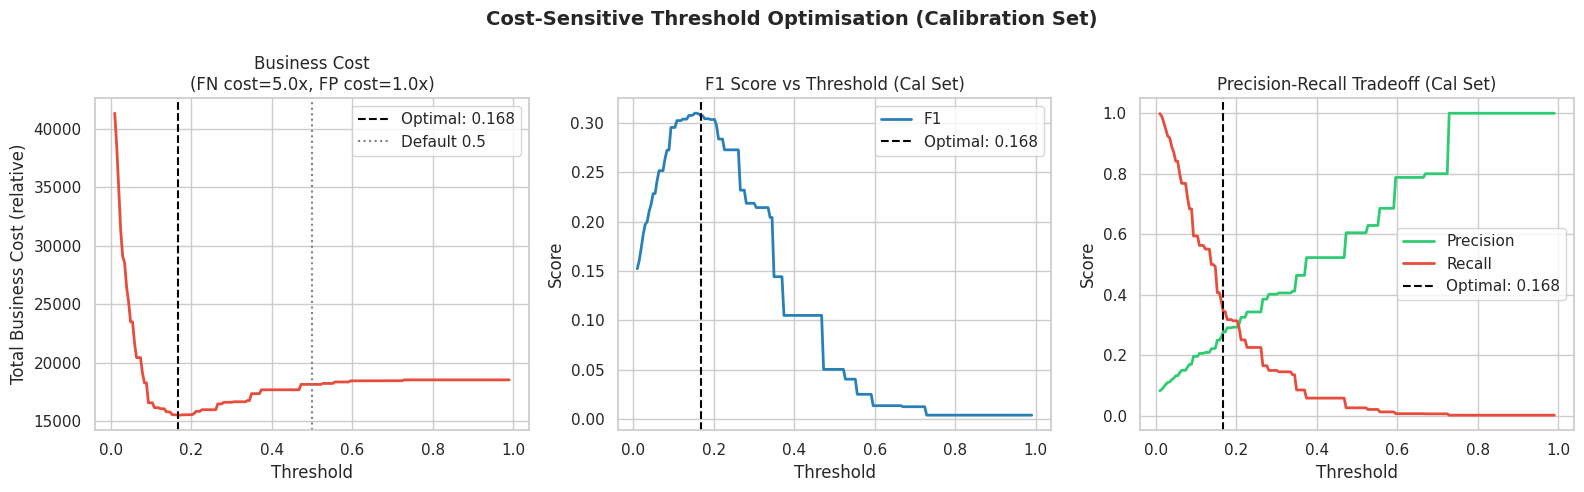


Default threshold (0.5) F1:  0.0506
Optimal threshold F1:        0.3070

 OPTIMAL_THRESHOLD, TIER_LOW_MAX, TIER_HIGH_MIN fixed. Now applying to test set.

Final Test-Set Classification Report:
              precision    recall  f1-score   support

  No Default       0.94      0.92      0.93     42403
     Default       0.28      0.35      0.31      3724

    accuracy                           0.88     46127
   macro avg       0.61      0.64      0.62     46127
weighted avg       0.89      0.88      0.88     46127



In [12]:
# ── Cost-Sensitive Threshold Optimisation (on calibration set) ───────────────
COST_FN = 5.0   # cost of missing a defaulter (relative)
COST_FP = 1.0   # cost of rejecting a good borrower

thresholds = np.linspace(0.01, 0.99, 200)
costs_cal, f1s_cal, precisions_cal, recalls_cal = [], [], [], []

for t in thresholds:
    y_pred_cal = (PD_SCORES_CAL >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_cal, y_pred_cal).ravel()
    costs_cal.append(COST_FN * fn + COST_FP * fp)
    f1s_cal.append(f1_score(y_cal, y_pred_cal, zero_division=0))
    precisions_cal.append(precision_score(y_cal, y_pred_cal, zero_division=0))
    recalls_cal.append(recall_score(y_cal, y_pred_cal, zero_division=0))

opt_idx           = np.argmin(costs_cal)
OPTIMAL_THRESHOLD = thresholds[opt_idx]   # ← single authoritative threshold
f1_at_05          = f1s_cal[np.argmin(np.abs(thresholds - 0.5))]
f1_at_opt         = f1s_cal[opt_idx]

# --- Data-driven risk tier boundaries ---
# Rather than arbitrary 30%/60% cutoffs, tiers are anchored to the cost-optimal threshold.
# LOW:    PD < optimal_threshold / 2    (comfortably below the decision line)
# MEDIUM: between threshold/2 and threshold*1.5 (review zone around the boundary)
# HIGH:   PD >= optimal_threshold * 1.5 (clearly above intervention line)
TIER_LOW_MAX  = OPTIMAL_THRESHOLD / 2
TIER_HIGH_MIN = OPTIMAL_THRESHOLD * 1.5

print(f"Optimal threshold (from calibration set): {OPTIMAL_THRESHOLD:.4f}")
print(f"  → LOW tier:    PD < {TIER_LOW_MAX:.4f}")
print(f"  → MEDIUM tier: {TIER_LOW_MAX:.4f} ≤ PD < {TIER_HIGH_MIN:.4f}")
print(f"  → HIGH tier:   PD ≥ {TIER_HIGH_MIN:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Cost-Sensitive Threshold Optimisation (Calibration Set)', fontsize=14, fontweight='bold')

ax = axes[0]
ax.plot(thresholds, costs_cal, color=COLORS['high'], lw=2)
ax.axvline(OPTIMAL_THRESHOLD, color='black', linestyle='--', label=f'Optimal: {OPTIMAL_THRESHOLD:.3f}')
ax.axvline(0.5, color='grey', linestyle=':', label='Default 0.5')
ax.set_xlabel('Threshold'); ax.set_ylabel('Total Business Cost (relative)')
ax.set_title(f'Business Cost\n(FN cost={COST_FN}x, FP cost={COST_FP}x)')
ax.legend()

ax = axes[1]
ax.plot(thresholds, f1s_cal, label='F1', color='#2980b9', lw=2)
ax.axvline(OPTIMAL_THRESHOLD, color='black', linestyle='--', label=f'Optimal: {OPTIMAL_THRESHOLD:.3f}')
ax.set_xlabel('Threshold'); ax.set_ylabel('Score')
ax.set_title('F1 Score vs Threshold (Cal Set)')
ax.legend()

ax = axes[2]
ax.plot(thresholds, precisions_cal, label='Precision', color=COLORS['low'], lw=2)
ax.plot(thresholds, recalls_cal,    label='Recall',    color=COLORS['high'], lw=2)
ax.axvline(OPTIMAL_THRESHOLD, color='black', linestyle='--', label=f'Optimal: {OPTIMAL_THRESHOLD:.3f}')
ax.set_xlabel('Threshold'); ax.set_ylabel('Score')
ax.set_title('Precision-Recall Tradeoff (Cal Set)')
ax.legend()

plt.tight_layout()
plt.savefig('threshold_optimisation.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nDefault threshold (0.5) F1:  {f1_at_05:.4f}")
print(f"Optimal threshold F1:        {f1_at_opt:.4f}")
print("\n OPTIMAL_THRESHOLD, TIER_LOW_MAX, TIER_HIGH_MIN fixed. Now applying to test set.")

# ── NOW apply calibrated model to test set ONCE ──────────────────────────────
PD_SCORES = calibrated_xgb.predict_proba(X_test)[:, 1]   # first and only use of X_test
Y_PRED    = (PD_SCORES >= OPTIMAL_THRESHOLD).astype(int)

print("\nFinal Test-Set Classification Report:")
print(classification_report(y_test, Y_PRED, target_names=['No Default','Default']))

---
## Step 6 — SHAP Explainability

### Global Feature Importance + Per-Applicant Explanations

SHAP (SHapley Additive exPlanations) answers two questions:
1. **Global:** Which features drive default risk across the portfolio?
2. **Local:** *Why* was this specific applicant flagged as high risk?

The second question is what a credit officer actually needs.

Computing SHAP values (this may take 1-2 minutes)...


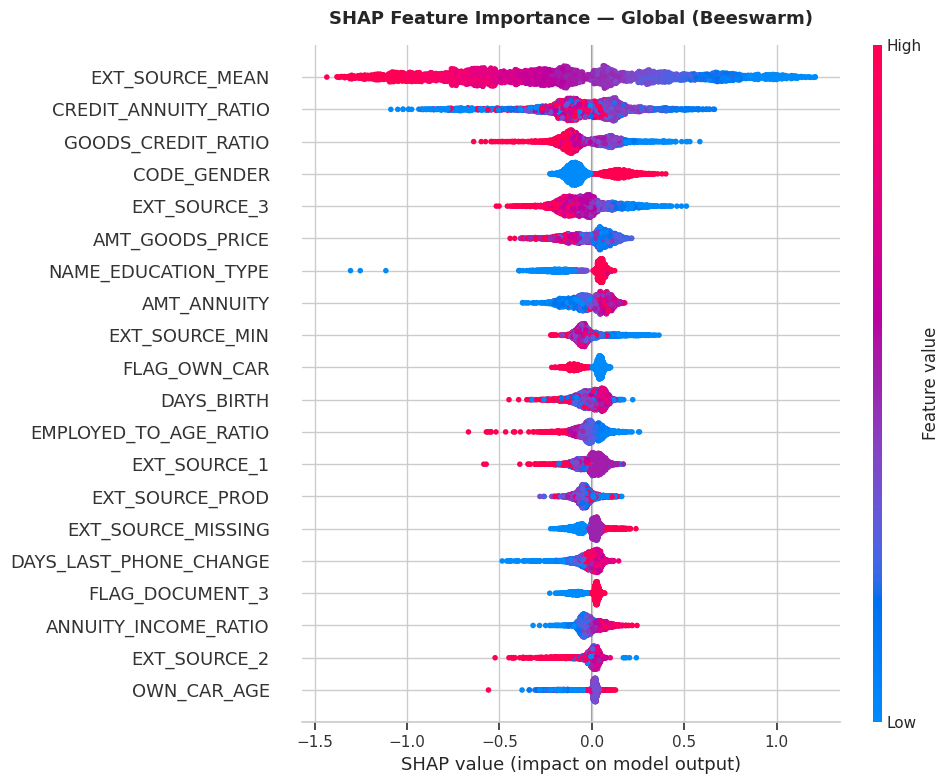

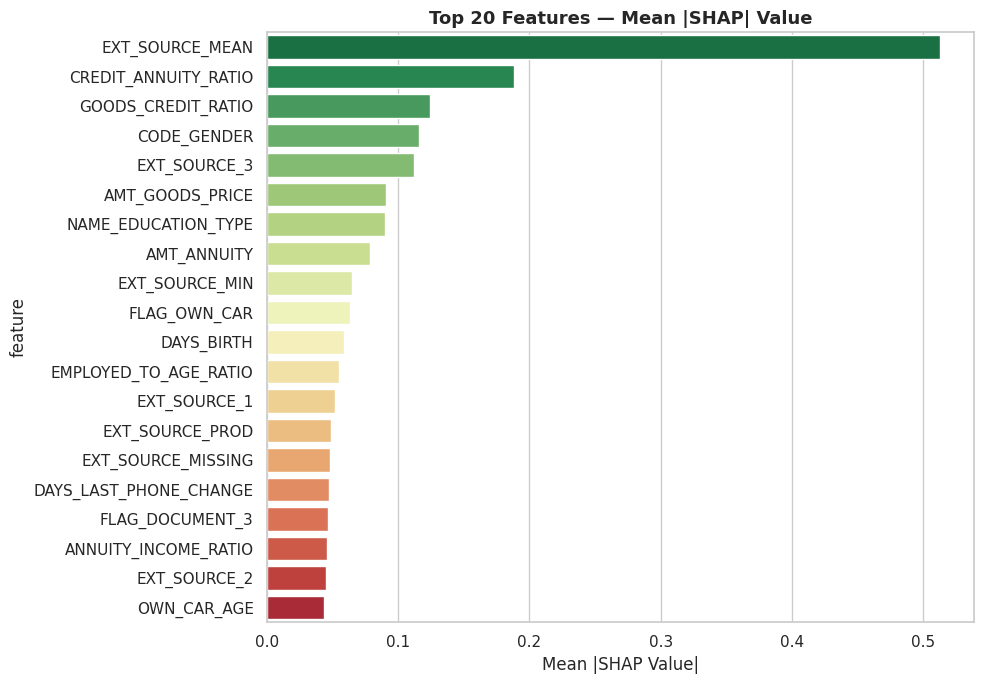


Top 10 risk drivers:
             feature  mean_abs_shap
     EXT_SOURCE_MEAN         0.5129
CREDIT_ANNUITY_RATIO         0.1879
  GOODS_CREDIT_RATIO         0.1242
         CODE_GENDER         0.1161
        EXT_SOURCE_3         0.1120
     AMT_GOODS_PRICE         0.0904
 NAME_EDUCATION_TYPE         0.0896
         AMT_ANNUITY         0.0783
      EXT_SOURCE_MIN         0.0645
        FLAG_OWN_CAR         0.0631

Global SHAP analysis complete


In [13]:
# ── SHAP — Global Analysis ─────────────────────────────────────────────────────
print("Computing SHAP values (this may take 1-2 minutes)...")

# Use a sample for speed
N_SHAP = min(3000, len(X_test))
X_shap_sample = X_test.iloc[:N_SHAP]

explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_shap_sample)

# --- Summary plot (beeswarm) ---
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_shap_sample, max_display=20,
                  show=False, plot_size=(10, 8))
plt.title('SHAP Feature Importance — Global (Beeswarm)', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Bar plot (mean |SHAP|) ---
shap_importance = pd.DataFrame({
    'feature': X_test.columns,
    'mean_abs_shap': np.abs(shap_values).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False).head(20)

plt.figure(figsize=(10, 7))
sns.barplot(data=shap_importance, y='feature', x='mean_abs_shap',
            palette='RdYlGn_r')
plt.title('Top 20 Features — Mean |SHAP| Value', fontsize=13, fontweight='bold')
plt.xlabel('Mean |SHAP Value|')
plt.tight_layout()
plt.savefig('shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 10 risk drivers:")
print(shap_importance[['feature','mean_abs_shap']].head(10).to_string(index=False))
print("\nGlobal SHAP analysis complete")

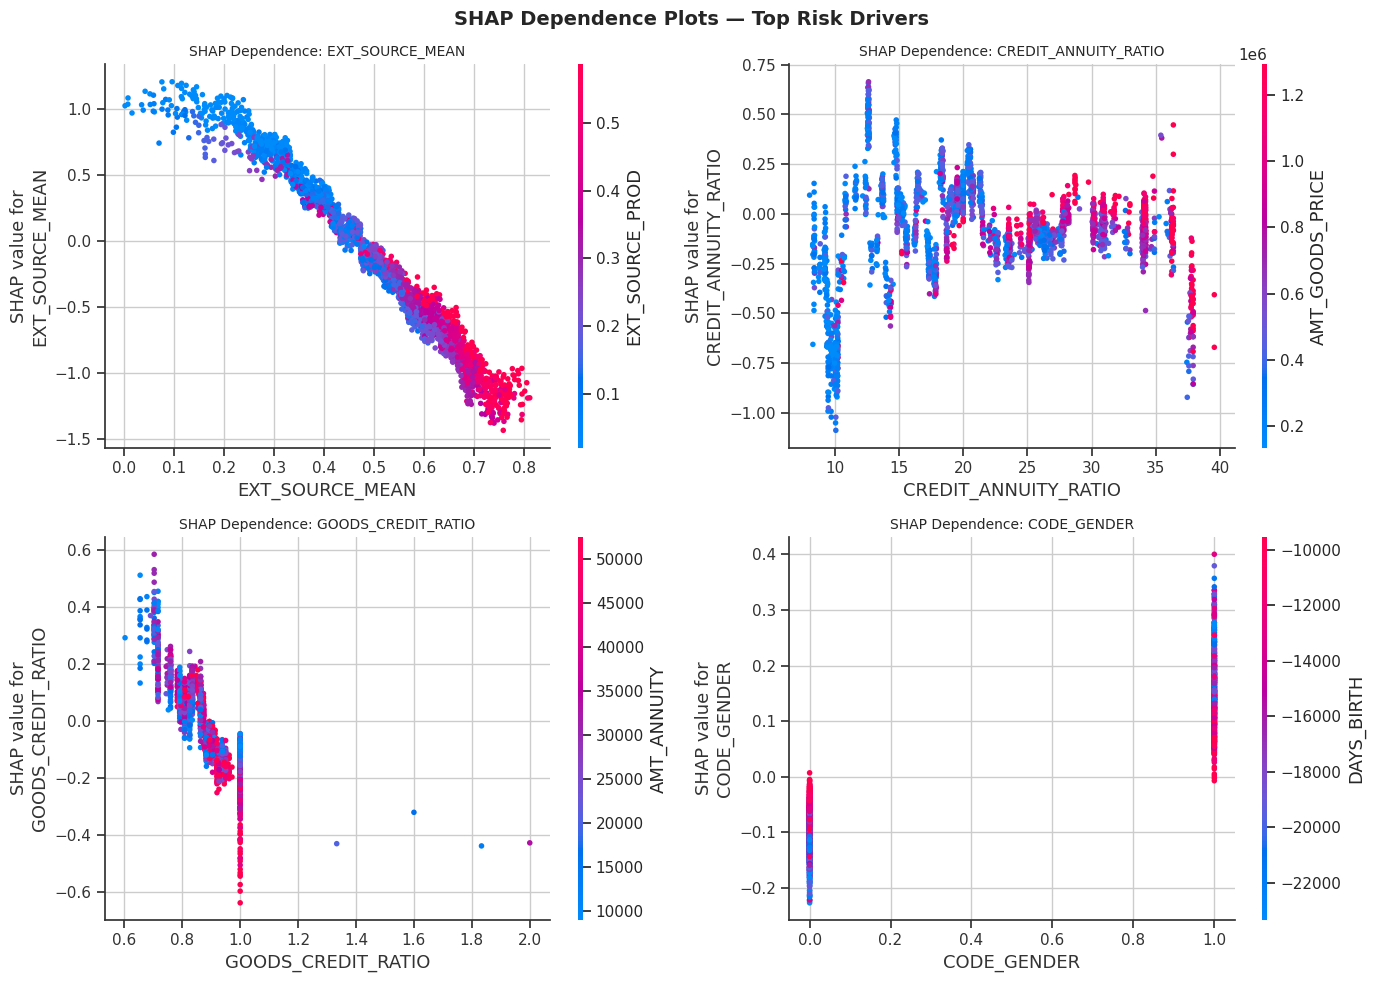

In [14]:
# ── SHAP Dependence Plots — Top 4 features ────────────────────────────────────
top4 = shap_importance['feature'].iloc[:4].tolist()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('SHAP Dependence Plots — Top Risk Drivers', fontsize=14, fontweight='bold')

for ax, feat in zip(axes.flatten(), top4):
    feat_idx = list(X_test.columns).index(feat)
    shap.dependence_plot(feat_idx, shap_values, X_shap_sample,
                         ax=ax, show=False)
    ax.set_title(f'SHAP Dependence: {feat}', fontsize=10)

plt.tight_layout()
plt.savefig('shap_dependence.png', dpi=150, bbox_inches='tight')
plt.show()

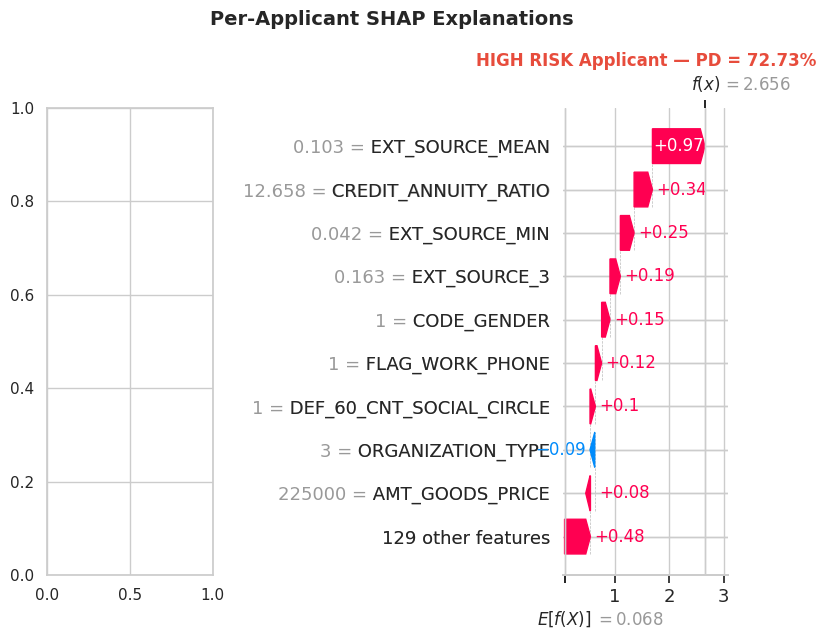

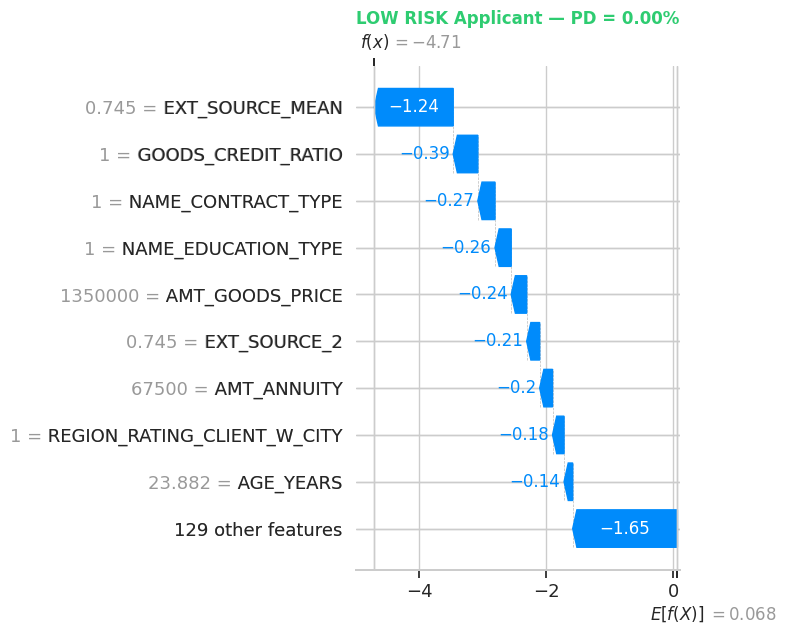

Per-applicant SHAP waterfall plots complete


In [15]:
# ── SHAP Waterfall — Individual Applicant Explanations ───────────────────────
# Find one high-risk and one low-risk applicant
test_df_shap = X_shap_sample.copy()
test_df_shap['PD'] = PD_SCORES[:N_SHAP]

high_risk_idx = test_df_shap.nlargest(1, 'PD').index[0]
low_risk_idx  = test_df_shap.nsmallest(1, 'PD').index[0]

high_risk_pos = list(X_shap_sample.index).index(high_risk_idx)
low_risk_pos  = list(X_shap_sample.index).index(low_risk_idx)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Per-Applicant SHAP Explanations', fontsize=14, fontweight='bold')

# Force plot (matplotlib version) for high risk
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[high_risk_pos],
        base_values=explainer.expected_value,
        data=X_shap_sample.iloc[high_risk_pos],
        feature_names=X_test.columns.tolist()
    ),
    max_display=10,
    show=False
)
plt.title(f'HIGH RISK Applicant — PD = {test_df_shap.loc[high_risk_idx, "PD"]:.2%}',
          color=COLORS['high'], fontweight='bold')
plt.tight_layout()
plt.savefig('shap_waterfall_high_risk.png', dpi=150, bbox_inches='tight')
plt.show()

shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[low_risk_pos],
        base_values=explainer.expected_value,
        data=X_shap_sample.iloc[low_risk_pos],
        feature_names=X_test.columns.tolist()
    ),
    max_display=10,
    show=False
)
plt.title(f'LOW RISK Applicant — PD = {test_df_shap.loc[low_risk_idx, "PD"]:.2%}',
          color=COLORS['low'], fontweight='bold')
plt.tight_layout()
plt.savefig('shap_waterfall_low_risk.png', dpi=150, bbox_inches='tight')
plt.show()

print("Per-applicant SHAP waterfall plots complete")

---
## Step 7 — Expected Loss Engine

**EL = PD × LGD × EAD** : the fundamental Basel II/III credit risk formula.

| Component | Definition | Source |
|---|---|---|
| **PD** | Probability of Default | XGBoost model (calibrated) |
| **LGD** | Loss Given Default | Assumed: 0.45 (Basel II retail standard) |
| **EAD** | Exposure at Default | `AMT_CREDIT` from application |

> LGD and EAD assumptions are clearly labelled.

In [16]:
# ── Expected Loss Engine ──────────────────────────────────────────────────────
# EL = PD × LGD × EAD
#
# LGD: fixed at 45% as an illustrative assumption for a public-data prototype.
#      The Home Credit dataset does not contain actual recovery information, so
#      LGD cannot be estimated from data. In a live system this would be modelled
#      separately from historical loss data.
# EAD: proxied by the application credit amount (AMT_CREDIT).
LGD_ASSUMPTION = 0.45   # illustrative : not a regulatory requirement

# Build the scoring dataframe (test set)
score_df = pd.DataFrame({
    'PD':            PD_SCORES,
    'EAD':           X_test['AMT_CREDIT'].values,
    'LGD':           LGD_ASSUMPTION,
    'Actual_Target': y_test.values
}, index=X_test.index)

# Expected Loss
score_df['EL']     = score_df['PD'] * score_df['LGD'] * score_df['EAD']
score_df['EL_pct'] = score_df['EL'] / score_df['EAD']

# --- Data-driven risk tiers (anchored to cost-optimal threshold from Step 5) ---
def assign_risk_tier(pd_score):
    if pd_score < TIER_LOW_MAX:   return 'LOW'
    elif pd_score < TIER_HIGH_MIN: return 'MEDIUM'
    else:                          return 'HIGH'

score_df['RISK_TIER'] = score_df['PD'].apply(assign_risk_tier)

# --- Decision engine (uses OPTIMAL_THRESHOLD from Step 5) ---
def assign_decision(pd_score):
    if pd_score < TIER_LOW_MAX:
        return 'APPROVE'
    elif pd_score < TIER_HIGH_MIN:
        return 'MANUAL_REVIEW'
    else:
        return 'DECLINE'

score_df['DECISION'] = score_df['PD'].apply(assign_decision)

tier_summary = score_df.groupby('RISK_TIER').agg(
    Count      = ('PD', 'count'),
    Avg_PD     = ('PD', 'mean'),
    Actual_DR  = ('Actual_Target', 'mean'),
    Avg_EAD    = ('EAD', 'mean'),
    Total_EL   = ('EL', 'sum'),
    Avg_EL_pct = ('EL_pct', 'mean')
).round(4)

print("\nRISK TIER SUMMARY (test set — unbiased)")
print("=" * 75)
print(f"Tier boundaries: LOW < {TIER_LOW_MAX:.4f} | {TIER_LOW_MAX:.4f} ≤ MEDIUM < {TIER_HIGH_MIN:.4f} | HIGH ≥ {TIER_HIGH_MIN:.4f}")
print("(Derived from cost-optimal threshold on calibration set — not arbitrary cutoffs)")
print()
print(tier_summary.to_string())
print()
print(f"Total Portfolio Expected Loss: {score_df['EL'].sum():,.0f} units")
print(f"Total Portfolio EAD:           {score_df['EAD'].sum():,.0f} units")
print(f"Portfolio EL Rate:             {score_df['EL'].sum()/score_df['EAD'].sum():.2%}")
print("\nNote: LGD=45% is an illustrative assumption; EAD=AMT_CREDIT. Rescale to ₹ as needed.")


RISK TIER SUMMARY (test set — unbiased)
Tier boundaries: LOW < 0.0838 | 0.0838 ≤ MEDIUM < 0.2514 | HIGH ≥ 0.2514
(Derived from cost-optimal threshold on calibration set — not arbitrary cutoffs)

           Count  Avg_PD  Actual_DR     Avg_EAD       Total_EL  Avg_EL_pct
RISK_TIER                                                                 
HIGH        2511  0.3456     0.3357 488657.0466 189845973.4948      0.1555
LOW        31037  0.0378     0.0360 623915.2105 324806446.3353      0.0170
MEDIUM     12579  0.1350     0.1402 553980.6507 419287792.3637      0.0607

Total Portfolio Expected Loss: 933,940,212 units
Total Portfolio EAD:           27,559,996,839 units
Portfolio EL Rate:             3.39%

Note: LGD=45% is an illustrative assumption; EAD=AMT_CREDIT. Rescale to ₹ as needed.


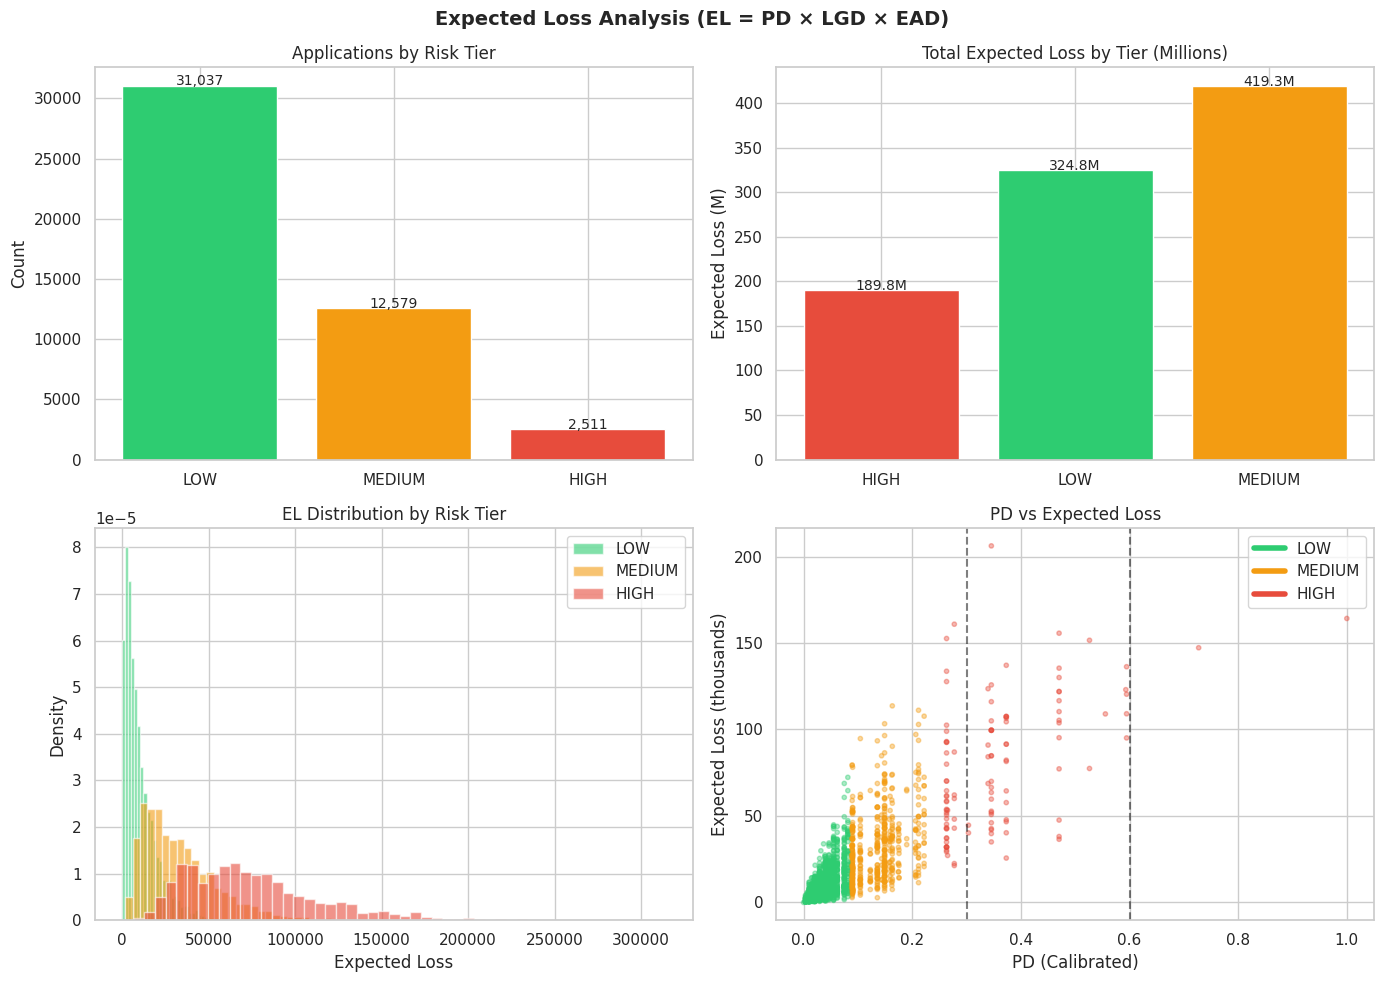

Expected Loss engine complete


In [17]:
# ── Expected Loss Visualisations ──────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Expected Loss Analysis (EL = PD × LGD × EAD)', fontsize=14, fontweight='bold')

tier_colors = {'LOW': COLORS['low'], 'MEDIUM': COLORS['medium'], 'HIGH': COLORS['high']}

# 1. Count by tier
ax = axes[0, 0]
tier_counts = score_df['RISK_TIER'].value_counts()
bars = ax.bar(tier_counts.index, tier_counts.values,
              color=[tier_colors[t] for t in tier_counts.index], edgecolor='white')
for bar, val in zip(bars, tier_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{val:,}', ha='center', fontsize=10)
ax.set_title('Applications by Risk Tier')
ax.set_ylabel('Count')

# 2. Total EL by tier
ax = axes[0, 1]
el_by_tier = score_df.groupby('RISK_TIER')['EL'].sum()
bars = ax.bar(el_by_tier.index, el_by_tier.values / 1e6,
              color=[tier_colors[t] for t in el_by_tier.index], edgecolor='white')
for bar, val in zip(bars, el_by_tier.values / 1e6):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{val:.1f}M', ha='center', fontsize=10)
ax.set_title('Total Expected Loss by Tier (Millions)')
ax.set_ylabel('Expected Loss (M)')

# 3. EL distribution
ax = axes[1, 0]
for tier, col in tier_colors.items():
    subset = score_df[score_df['RISK_TIER']==tier]['EL']
    ax.hist(subset, bins=50, alpha=0.6, label=tier, color=col, density=True)
ax.set_title('EL Distribution by Risk Tier')
ax.set_xlabel('Expected Loss')
ax.set_ylabel('Density')
ax.legend()

# 4. PD vs EL scatter (sampled)
ax = axes[1, 1]
sample_plot = score_df.sample(min(2000, len(score_df)), random_state=42)
scatter_colors = [tier_colors[t] for t in sample_plot['RISK_TIER']]
ax.scatter(sample_plot['PD'], sample_plot['EL']/1000,
           c=scatter_colors, alpha=0.4, s=10)
ax.axvline(0.30, color='black', linestyle='--', alpha=0.5, label='Tier boundaries')
ax.axvline(0.60, color='black', linestyle='--', alpha=0.5)
ax.set_xlabel('PD (Calibrated)')
ax.set_ylabel('Expected Loss (thousands)')
ax.set_title('PD vs Expected Loss')
ax.legend([plt.Line2D([0],[0], color=c, lw=4) for c in tier_colors.values()],
           tier_colors.keys())

plt.tight_layout()
plt.savefig('expected_loss_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Expected Loss engine complete")

---
## Step 8 — Risk Segmentation & Decision Engine

Three-tier system with recommended credit actions.

In [18]:
# ── Decision Engine Analysis ──────────────────────────────────────────────────
decision_accuracy = score_df.groupby('DECISION').agg(
    Count        = ('PD', 'count'),
    Pct_of_total = ('PD', lambda x: len(x)/len(score_df)*100),
    Actual_DR    = ('Actual_Target', 'mean'),
    Avg_PD       = ('PD', 'mean'),
    Total_EL_M   = ('EL', lambda x: x.sum()/1e6)
).round(4)

print("\n DECISION ENGINE RESULTS (test set)")
print("=" * 75)
print(decision_accuracy.to_string())

print("\n" + "="*75)
print("TIER INTERPRETATION")
print("=" * 75)
TIER_ACTIONS = {
    'LOW':    'APPROVE          — straight-through processing',
    'MEDIUM': 'MANUAL REVIEW    — route to credit officer; request additional documents',
    'HIGH':   'DECLINE          — reject application; note for early-warning if existing customer'
}
for tier, row in tier_summary.iterrows():
    n      = int(row['Count'])
    pd_avg = row['Avg_PD']
    dr     = row['Actual_DR']
    el     = row['Total_EL']
    print(f"\n{tier} RISK  ({n:,} applicants)")
    print(f"  Action:    {TIER_ACTIONS[tier]}")
    print(f"  Avg PD:    {pd_avg:.1%}")
    print(f"  Actual DR: {dr:.1%}  ← tier {'well' if abs(pd_avg-dr)<0.05 else 'roughly'} calibrated")
    print(f"  Total EL:  {el/1e6:.2f}M units")



 DECISION ENGINE RESULTS (test set)
               Count  Pct_of_total  Actual_DR  Avg_PD  Total_EL_M
DECISION                                                         
APPROVE        31037       67.2860     0.0360  0.0378    324.8064
DECLINE         2511        5.4437     0.3357  0.3456    189.8460
MANUAL_REVIEW  12579       27.2704     0.1402  0.1350    419.2878

TIER INTERPRETATION

HIGH RISK  (2,511 applicants)
  Action:    DECLINE          — reject application; note for early-warning if existing customer
  Avg PD:    34.6%
  Actual DR: 33.6%  ← tier well calibrated
  Total EL:  189.85M units

LOW RISK  (31,037 applicants)
  Action:    APPROVE          — straight-through processing
  Avg PD:    3.8%
  Actual DR: 3.6%  ← tier well calibrated
  Total EL:  324.81M units

MEDIUM RISK  (12,579 applicants)
  Action:    MANUAL REVIEW    — route to credit officer; request additional documents
  Avg PD:    13.5%
  Actual DR: 14.0%  ← tier well calibrated
  Total EL:  419.29M units


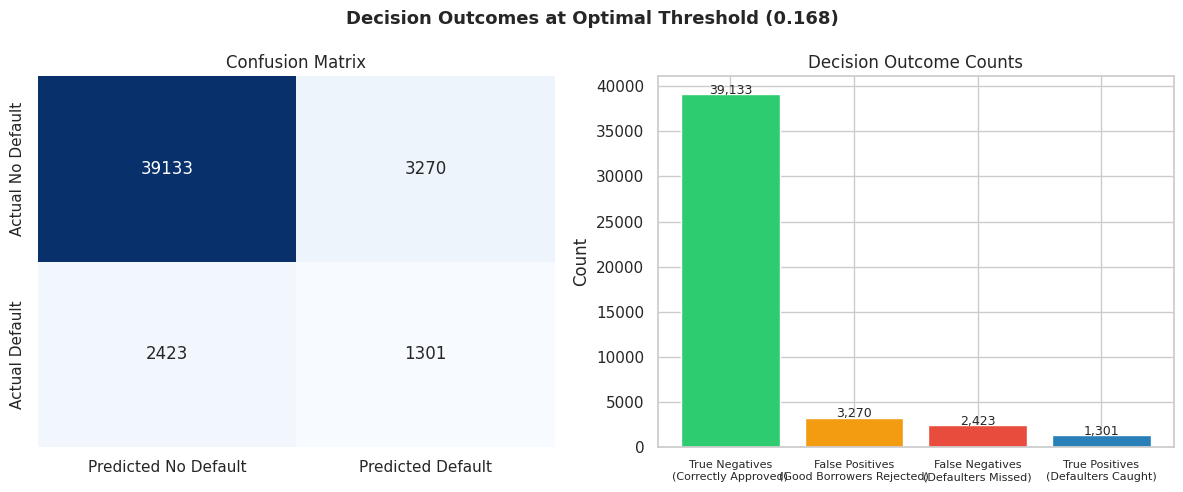

False Negative Rate (defaulters missed):       65.06%
False Positive Rate (good borrowers rejected): 7.71%
Recall on defaulters (Sensitivity):            34.94%


In [19]:
# ── Confusion Matrix at Optimal Threshold ────────────────────────────────────
cm = confusion_matrix(y_test, Y_PRED)
tn, fp, fn, tp = cm.ravel()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle(f'Decision Outcomes at Optimal Threshold ({OPTIMAL_THRESHOLD:.3f})',
             fontsize=13, fontweight='bold')

# Confusion matrix heatmap
cm_pct = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap([[tn, fp],[fn, tp]], annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted No Default','Predicted Default'],
            yticklabels=['Actual No Default','Actual Default'],
            ax=ax1, cbar=False)
ax1.set_title('Confusion Matrix')

# Business cost breakdown
categories = ['True Negatives\n(Correctly Approved)', 'False Positives\n(Good Borrowers Rejected)',
              'False Negatives\n(Defaulters Missed)', 'True Positives\n(Defaulters Caught)']
values = [tn, fp, fn, tp]
bar_colors = [COLORS['low'], COLORS['medium'], COLORS['high'], '#2980b9']
bars = ax2.bar(range(4), values, color=bar_colors, edgecolor='white')
ax2.set_xticks(range(4))
ax2.set_xticklabels(categories, fontsize=8)
for bar, val in zip(bars, values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             f'{val:,}', ha='center', fontsize=9)
ax2.set_title('Decision Outcome Counts')
ax2.set_ylabel('Count')

plt.tight_layout()
plt.savefig('decision_outcomes.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"False Negative Rate (defaulters missed):       {fn/(fn+tp):.2%}")
print(f"False Positive Rate (good borrowers rejected): {fp/(fp+tn):.2%}")
print(f"Recall on defaulters (Sensitivity):            {tp/(tp+fn):.2%}")

---
## Step 9 — Portfolio Dashboard

A full portfolio-level summary.

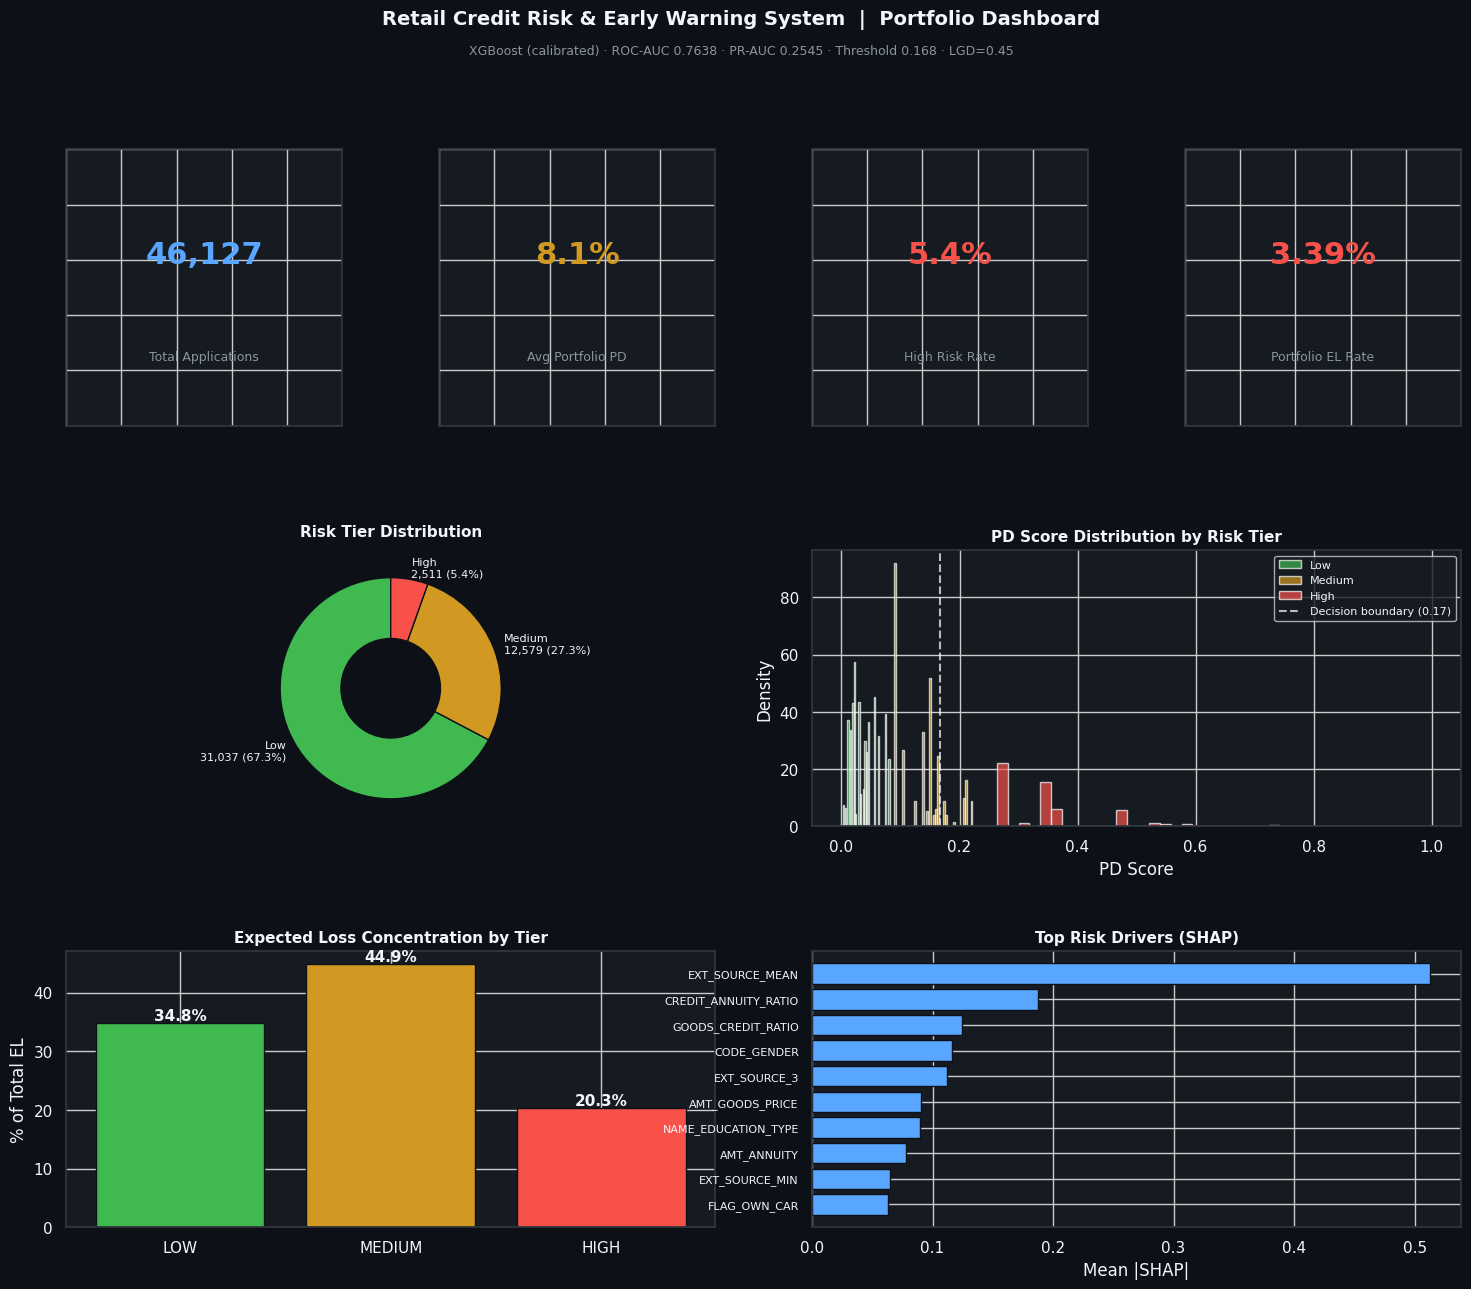

Portfolio dashboard saved


In [20]:
# ── Portfolio Dashboard ───────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 14))
fig.patch.set_facecolor('#0d1117')
gs = gridspec.GridSpec(3, 4, figure=fig, hspace=0.45, wspace=0.35)

DASH_BG   = '#0d1117'
CARD_BG   = '#161b22'
TEXT_COL  = '#f0f6fc'
GREEN_COL = '#3fb950'
RED_COL   = '#f85149'
ORG_COL   = '#d29922'
BLUE_COL  = '#58a6ff'

def kpi_card(ax, value, label, color, prefix='', suffix=''):
    ax.set_facecolor(CARD_BG)
    ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
    for sp in ax.spines.values(): sp.set_color('#30363d')
    ax.text(0.5, 0.62, f'{prefix}{value}{suffix}', transform=ax.transAxes,
            ha='center', va='center', fontsize=22, fontweight='bold', color=color)
    ax.text(0.5, 0.25, label, transform=ax.transAxes,
            ha='center', va='center', fontsize=9, color='#8b949e')

# KPI row
n_total  = len(score_df)
n_high   = (score_df['RISK_TIER']=='HIGH').sum()
n_medium = (score_df['RISK_TIER']=='MEDIUM').sum()
n_low    = (score_df['RISK_TIER']=='LOW').sum()
avg_pd   = score_df['PD'].mean()
total_el = score_df['EL'].sum()
total_ead= score_df['EAD'].sum()

ax = fig.add_subplot(gs[0, 0])
kpi_card(ax, f"{n_total:,}", 'Total Applications', BLUE_COL)

ax = fig.add_subplot(gs[0, 1])
kpi_card(ax, f"{avg_pd:.1%}", 'Avg Portfolio PD', ORG_COL)

ax = fig.add_subplot(gs[0, 2])
kpi_card(ax, f"{n_high/n_total:.1%}", 'High Risk Rate', RED_COL)

ax = fig.add_subplot(gs[0, 3])
kpi_card(ax, f"{total_el/total_ead:.2%}", 'Portfolio EL Rate', RED_COL)

# Risk distribution donut
ax = fig.add_subplot(gs[1, 0:2])
ax.set_facecolor(CARD_BG)
sizes  = [n_low, n_medium, n_high]
labels = [f'Low\n{n_low:,} ({n_low/n_total:.1%})',
          f'Medium\n{n_medium:,} ({n_medium/n_total:.1%})',
          f'High\n{n_high:,} ({n_high/n_total:.1%})']
wedges, texts = ax.pie(sizes, labels=labels, colors=[GREEN_COL, ORG_COL, RED_COL],
                       startangle=90, wedgeprops=dict(width=0.55, edgecolor=DASH_BG))
for t in texts: t.set_color(TEXT_COL); t.set_fontsize(8)
ax.set_title('Risk Tier Distribution', color=TEXT_COL, fontsize=11, fontweight='bold', pad=10)

# PD distribution histogram
ax = fig.add_subplot(gs[1, 2:4])
ax.set_facecolor(CARD_BG)
ax.hist(score_df[score_df['RISK_TIER']=='LOW']['PD'],    bins=40, alpha=0.7, color=GREEN_COL, label='Low',   density=True)
ax.hist(score_df[score_df['RISK_TIER']=='MEDIUM']['PD'], bins=40, alpha=0.7, color=ORG_COL,   label='Medium',density=True)
ax.hist(score_df[score_df['RISK_TIER']=='HIGH']['PD'],   bins=40, alpha=0.7, color=RED_COL,   label='High',  density=True)
ax.axvline(OPTIMAL_THRESHOLD, color='white', linestyle='--', alpha=0.7, lw=1.5, label=f'Decision boundary ({OPTIMAL_THRESHOLD:.2f})')
ax.set_facecolor(CARD_BG)
ax.tick_params(colors=TEXT_COL)
ax.set_xlabel('PD Score', color=TEXT_COL)
ax.set_ylabel('Density', color=TEXT_COL)
ax.set_title('PD Score Distribution by Risk Tier', color=TEXT_COL, fontsize=11, fontweight='bold')
ax.legend(fontsize=8, labelcolor=TEXT_COL, facecolor=CARD_BG)
for sp in ax.spines.values(): sp.set_color('#30363d')

# EL concentration (high risk holds most EL)
ax = fig.add_subplot(gs[2, 0:2])
ax.set_facecolor(CARD_BG)
el_by_tier = score_df.groupby('RISK_TIER')['EL'].sum()
el_pct = (el_by_tier / el_by_tier.sum() * 100).reindex(['LOW','MEDIUM','HIGH'])
bars = ax.bar(el_pct.index, el_pct.values,
              color=[GREEN_COL, ORG_COL, RED_COL], edgecolor=DASH_BG)
for bar, val in zip(bars, el_pct.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', fontsize=11, color=TEXT_COL, fontweight='bold')
ax.set_facecolor(CARD_BG)
ax.tick_params(colors=TEXT_COL)
ax.set_ylabel('% of Total EL', color=TEXT_COL)
ax.set_title('Expected Loss Concentration by Tier', color=TEXT_COL, fontsize=11, fontweight='bold')
for sp in ax.spines.values(): sp.set_color('#30363d')

# SHAP top features bar
ax = fig.add_subplot(gs[2, 2:4])
ax.set_facecolor(CARD_BG)
top10 = shap_importance.head(10)
ax.barh(range(len(top10)), top10['mean_abs_shap'].values,
        color=[BLUE_COL]*len(top10), edgecolor=DASH_BG)
ax.set_yticks(range(len(top10)))
ax.set_yticklabels(top10['feature'].tolist(), fontsize=8, color=TEXT_COL)
ax.set_xlabel('Mean |SHAP|', color=TEXT_COL)
ax.set_title('Top Risk Drivers (SHAP)', color=TEXT_COL, fontsize=11, fontweight='bold')
ax.tick_params(colors=TEXT_COL)
for sp in ax.spines.values(): sp.set_color('#30363d')
ax.invert_yaxis()

# Title
fig.text(0.5, 0.98,
         'Retail Credit Risk & Early Warning System  |  Portfolio Dashboard',
         ha='center', va='top', fontsize=14, fontweight='bold', color=TEXT_COL)
fig.text(0.5, 0.955,
         f'XGBoost (calibrated) · ROC-AUC {results["XGBoost"]["roc"]:.4f} · PR-AUC {results["XGBoost"]["pr"]:.4f} · Threshold {OPTIMAL_THRESHOLD:.3f} · LGD={LGD_ASSUMPTION}',
         ha='center', va='top', fontsize=9, color='#8b949e')

plt.savefig('portfolio_dashboard.png', dpi=150, bbox_inches='tight', facecolor=DASH_BG)
plt.show()
print("Portfolio dashboard saved")

---
## Step 10 — Applicant-Level Explanation Report

Function that generates a full credit decision card for any individual applicant.

Generating report for HIGH RISK applicant...


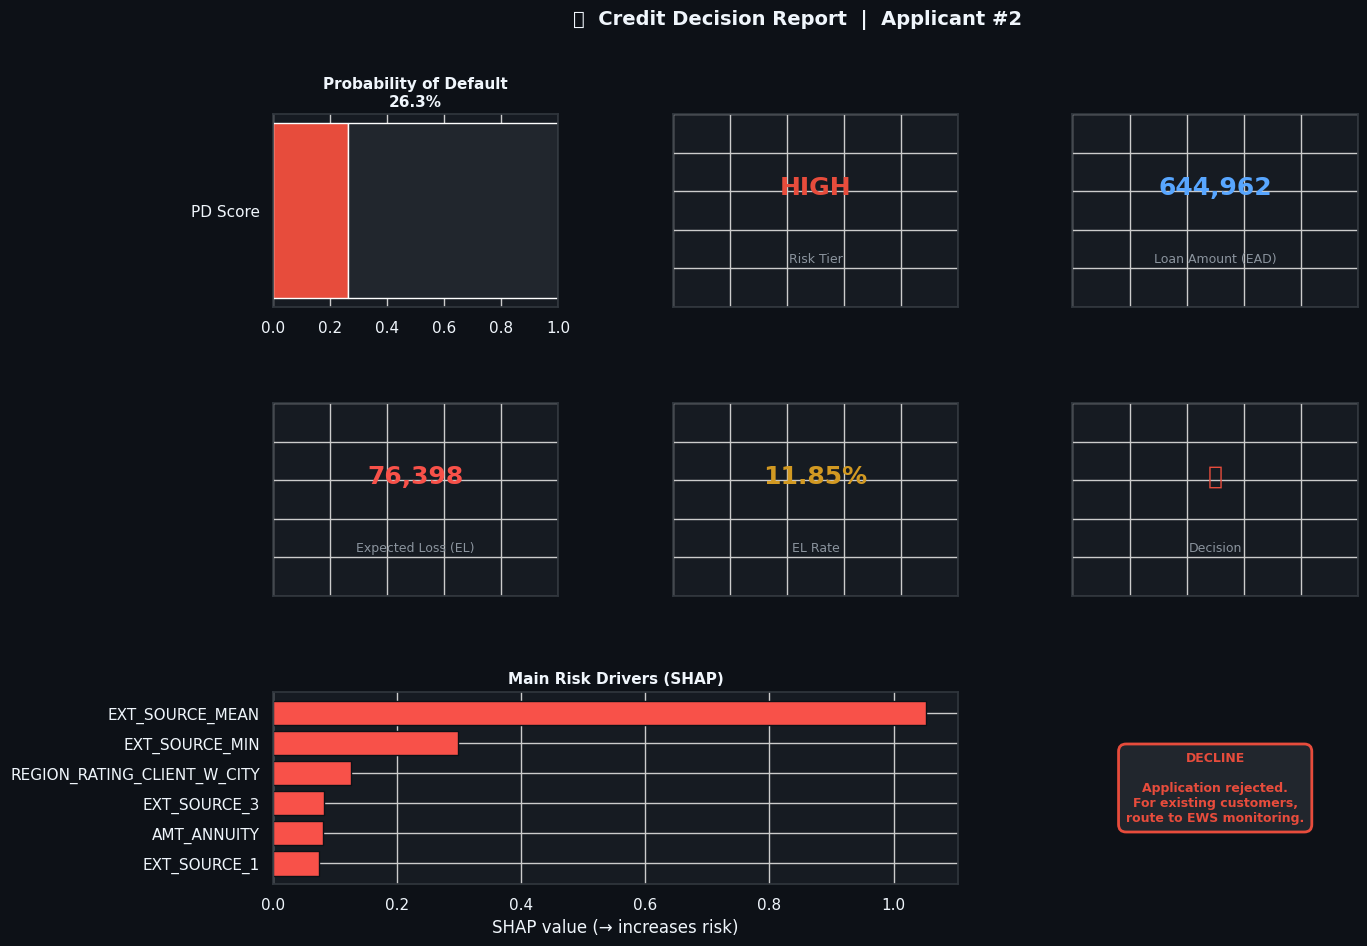

Generating report for LOW RISK applicant...


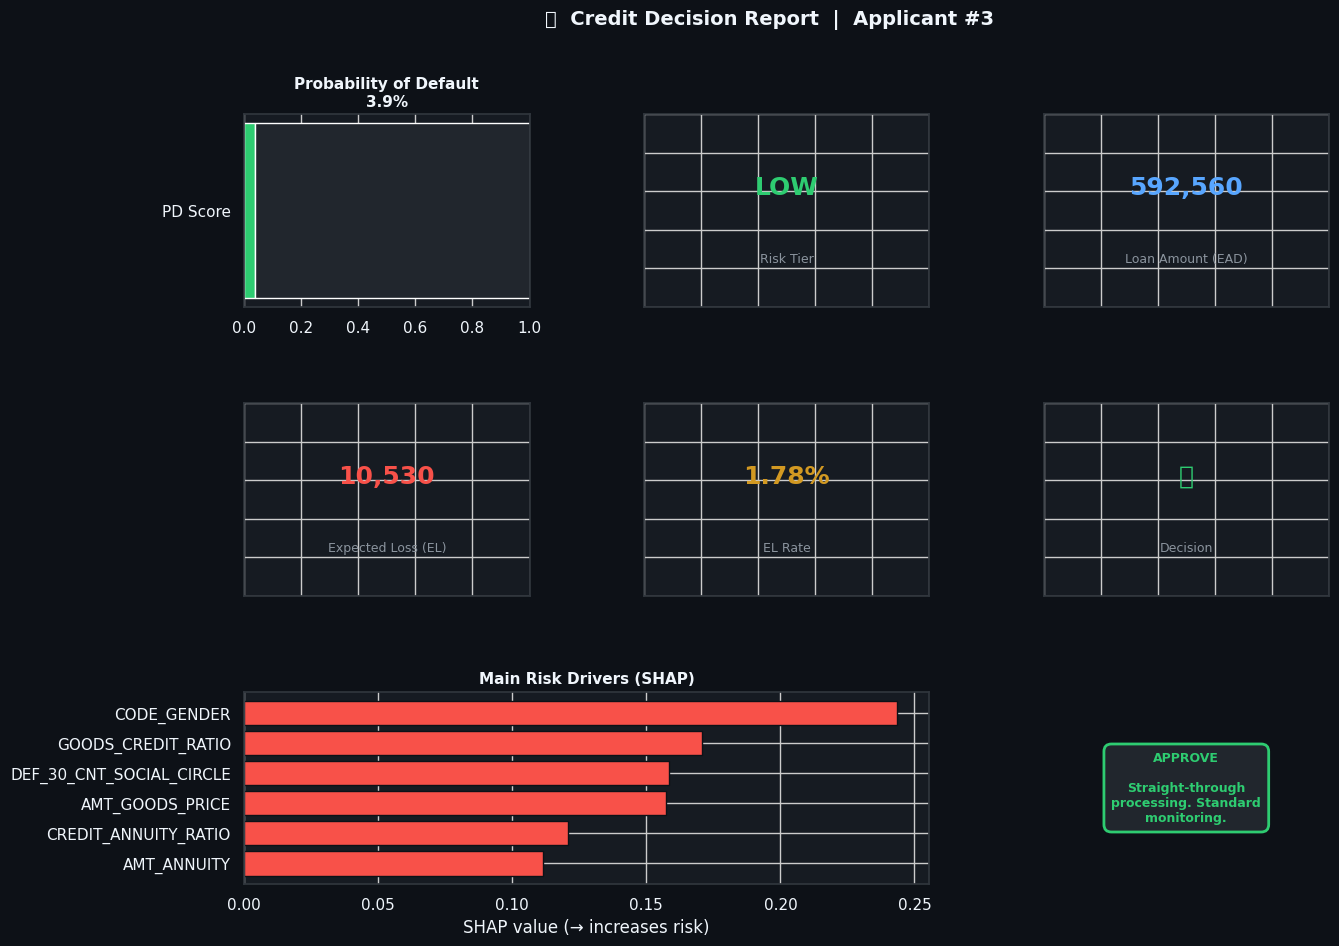

 Applicant reports generated


In [21]:
# ── Applicant-Level Decision Report ──────────────────────────────────────────
def generate_applicant_report(applicant_idx, score_df, X_test, shap_values,
                               X_shap_sample, explainer, top_n=6):
    """
    Generate a credit officer decision card for a single applicant.
    applicant_idx: integer position in X_test
    """
    # Get data
    score_row  = score_df.iloc[applicant_idx]
    pd_score   = score_row['PD']
    ead        = score_row['EAD']
    lgd        = score_row['LGD']
    el         = score_row['EL']
    tier       = score_row['RISK_TIER']
    decision   = score_row['DECISION']

    # SHAP (if available in sample)
    try:
        shap_idx  = list(X_shap_sample.index).index(X_test.index[applicant_idx])
        sv        = shap_values[shap_idx]
        feat_vals = X_shap_sample.iloc[shap_idx]
        shap_df   = pd.DataFrame({'feature': X_test.columns, 'shap': sv, 'value': feat_vals.values})
        risk_drivers    = shap_df.nlargest(top_n, 'shap')
        protect_factors = shap_df.nsmallest(top_n, 'shap')
    except (ValueError, IndexError):
        risk_drivers    = None
        protect_factors = None

    tier_color = {'LOW': COLORS['low'], 'MEDIUM': COLORS['medium'], 'HIGH': COLORS['high']}[tier]
    decision_icon = {'APPROVE': '✅', 'MANUAL_REVIEW': '⚠️', 'DECLINE':              '❌'}.get(decision, '?')

    # Plot
    fig = plt.figure(figsize=(14, 10))
    fig.patch.set_facecolor('#0d1117')
    gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.5, wspace=0.4)

    # Header
    fig.text(0.5, 0.97,
             f'🏦  Credit Decision Report  |  Applicant #{applicant_idx}',
             ha='center', fontsize=14, fontweight='bold', color='#f0f6fc')

    # PD gauge (simple bar)
    ax = fig.add_subplot(gs[0, 0])
    ax.set_facecolor('#161b22')
    ax.barh(['PD Score'], [pd_score], color=tier_color, height=0.4)
    ax.barh(['PD Score'], [1-pd_score], left=[pd_score], color='#21262d', height=0.4)
    ax.set_xlim(0, 1)
    ax.set_title(f'Probability of Default\n{pd_score:.1%}', color='#f0f6fc', fontsize=11, fontweight='bold')
    ax.tick_params(colors='#f0f6fc')
    for sp in ax.spines.values(): sp.set_color('#30363d')

    # KPI cards
    for i, (val, lbl, col) in enumerate([
        (f'{tier}',        f'Risk Tier',        tier_color),
        (f'{ead:,.0f}',    f'Loan Amount (EAD)', '#58a6ff'),
        (f'{el:,.0f}',     f'Expected Loss (EL)','#f85149'),
        (f'{el/ead:.2%}',  f'EL Rate',           '#d29922'),
        (decision_icon,    f'Decision',          tier_color),
    ]):
        row, col_idx = divmod(i + 1, 3)
        if row < 3 and col_idx < 3:
            a = fig.add_subplot(gs[min(row,2), col_idx])
            a.set_facecolor('#161b22')
            a.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
            for sp in a.spines.values(): sp.set_color('#30363d')
            a.text(0.5, 0.62, val, transform=a.transAxes,
                   ha='center', va='center', fontsize=18, fontweight='bold', color=col)
            a.text(0.5, 0.25, lbl, transform=a.transAxes,
                   ha='center', va='center', fontsize=9, color='#8b949e')

    # Risk drivers bar chart
    if risk_drivers is not None:
        ax_rd = fig.add_subplot(gs[2, 0:2])
        ax_rd.set_facecolor('#161b22')
        colors_rd = ['#f85149' if v > 0 else '#3fb950' for v in risk_drivers['shap'].values]
        ax_rd.barh(risk_drivers['feature'][::-1], risk_drivers['shap'].values[::-1],
                   color=colors_rd[::-1], edgecolor='#0d1117')
        ax_rd.axvline(0, color='#8b949e', linewidth=0.8)
        ax_rd.set_title('Main Risk Drivers (SHAP)', color='#f0f6fc', fontsize=11, fontweight='bold')
        ax_rd.tick_params(colors='#f0f6fc')
        for sp in ax_rd.spines.values(): sp.set_color('#30363d')
        ax_rd.set_xlabel('SHAP value (→ increases risk)', color='#f0f6fc')

    # Decision recommendation box
    ax_d = fig.add_subplot(gs[2, 2])
    ax_d.set_facecolor('#161b22')
    ax_d.axis('off')
    decision_text = {
        'APPROVE':              'APPROVE\n\nStraight-through\nprocessing. Standard\nmonitoring.',
        'MANUAL_REVIEW':        'MANUAL REVIEW\n\nRoute to credit\nofficer. Request\nadditional documents.',
        'DECLINE':              'DECLINE\n\nApplication rejected.\nFor existing customers,\nroute to EWS monitoring.'
    }.get(decision, decision)
    ax_d.text(0.5, 0.5, decision_text, transform=ax_d.transAxes,
              ha='center', va='center', fontsize=9, color=tier_color,
              fontweight='bold', wrap=True, multialignment='center',
              bbox=dict(boxstyle='round,pad=0.6', facecolor='#21262d', edgecolor=tier_color, lw=2))

    plt.savefig(f'applicant_report_{applicant_idx}.png', dpi=150, bbox_inches='tight',
                facecolor='#0d1117')
    plt.show()

# Generate report for a HIGH RISK applicant
high_risk_applicant = score_df[score_df['RISK_TIER']=='HIGH'].index[0]
high_pos = list(X_test.index).index(high_risk_applicant)
print("Generating report for HIGH RISK applicant...")
generate_applicant_report(high_pos, score_df, X_test, shap_values, X_shap_sample, explainer)

# Generate report for a LOW RISK applicant
low_risk_applicant = score_df[score_df['RISK_TIER']=='LOW'].index[0]
low_pos = list(X_test.index).index(low_risk_applicant)
print("Generating report for LOW RISK applicant...")
generate_applicant_report(low_pos, score_df, X_test, shap_values, X_shap_sample, explainer)

print(" Applicant reports generated")

---
## Step 11 — Model Monitoring: PSI & KS Stability

Production credit models require ongoing monitoring.  
We demonstrate monitoring concepts using a **simulated population split** of the test set.

> **Note:** The Home Credit dataset does not provide a production-style temporal scoring stream,
> so this is a simulated distribution-shift exercise, not genuine temporal monitoring.
> In production, Period 1 would be the model's first deployment month and Period 2 a later
> scoring window. The PSI and KS functions below transfer directly to that setting.

| Metric | What it measures |
|---|---|
| **PSI** (Population Stability Index) | Distribution shift in model scores |
| **KS Statistic** | Discriminatory power between defaults and non-defaults |

**PSI interpretation:** <0.1 = stable, 0.1-0.25 = slight shift, >0.25 = significant shift.

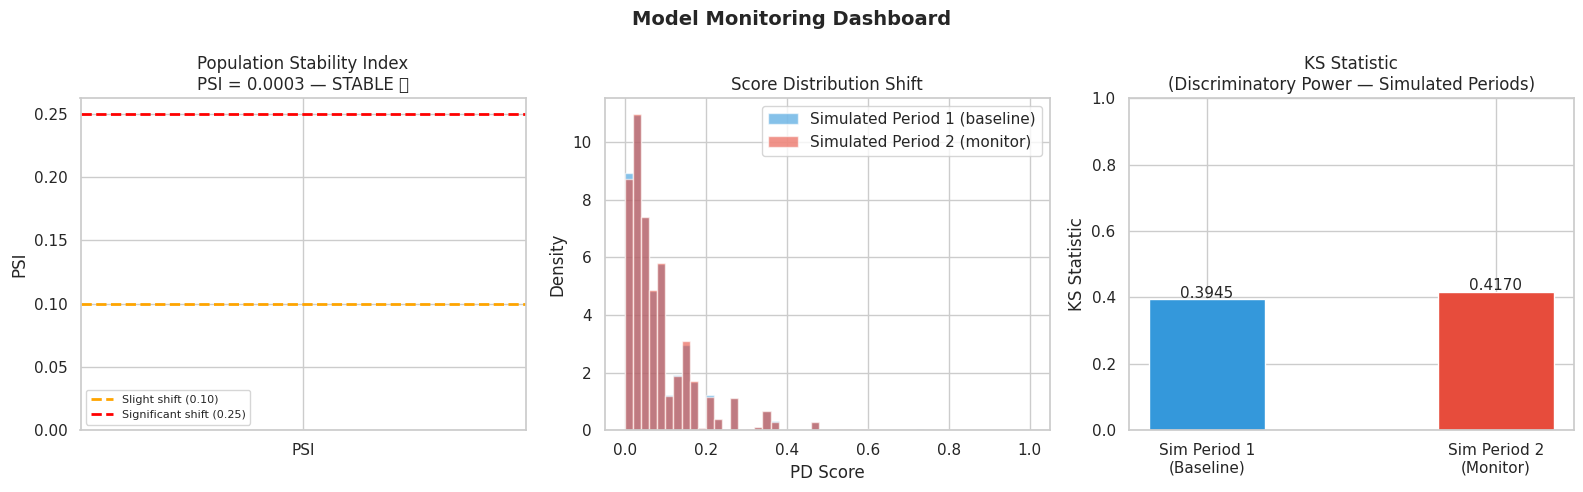

PSI:               0.00029  → STABLE ✅
KS (Period 1):     0.3945
KS (Period 2):     0.4170
KS change:         +5.69%


In [22]:
# ── Model Monitoring — PSI & KS ───────────────────────────────────────────────
def compute_psi(expected, actual, bins=10):
    """Population Stability Index."""
    breakpoints = np.percentile(expected, np.linspace(0, 100, bins+1))
    breakpoints = np.unique(breakpoints)
    expected_pcts = np.histogram(expected, bins=breakpoints)[0] / len(expected)
    actual_pcts   = np.histogram(actual,   bins=breakpoints)[0] / len(actual)
    # Avoid log(0)
    expected_pcts = np.where(expected_pcts == 0, 1e-6, expected_pcts)
    actual_pcts   = np.where(actual_pcts   == 0, 1e-6, actual_pcts)
    psi_values = (actual_pcts - expected_pcts) * np.log(actual_pcts / expected_pcts)
    return np.sum(psi_values)

def compute_ks(probs, labels):
    """KS statistic between defaulters and non-defaulters."""
    default_probs    = probs[labels == 1]
    non_default_probs= probs[labels == 0]
    ks_stat, p_val   = ks_2samp(default_probs, non_default_probs)
    return ks_stat

# Simulated distribution shift: split test set in half as a proxy for two scoring windows.
# In production these would be genuine temporal cohorts.
# Labelled clearly as 'Simulated Period' throughout.
n_half   = len(PD_SCORES) // 2
probs_t0 = PD_SCORES[:n_half]
probs_t1 = PD_SCORES[n_half:]
labels_t0= y_test.values[:n_half]
labels_t1= y_test.values[n_half:]

psi = compute_psi(probs_t0, probs_t1)
ks_t0 = compute_ks(probs_t0, labels_t0)
ks_t1 = compute_ks(probs_t1, labels_t1)

psi_status = 'STABLE ✅' if psi < 0.1 else ('SLIGHT SHIFT ⚠️' if psi < 0.25 else 'SIGNIFICANT SHIFT ❌')

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Model Monitoring Dashboard', fontsize=14, fontweight='bold')

# PSI score gauge
ax = axes[0]
bar_col = '#2ecc71' if psi < 0.1 else ('#f39c12' if psi < 0.25 else '#e74c3c')
ax.bar(['PSI'], [psi], color=bar_col, width=0.4, edgecolor='white')
ax.axhline(0.10, color='orange', linestyle='--', lw=2, label='Slight shift (0.10)')
ax.axhline(0.25, color='red',    linestyle='--', lw=2, label='Significant shift (0.25)')
ax.set_title(f'Population Stability Index\nPSI = {psi:.4f} — {psi_status}')
ax.set_ylabel('PSI'); ax.legend(fontsize=8)

# Score distribution t0 vs t1
ax = axes[1]
ax.hist(probs_t0, bins=50, alpha=0.6, label='Simulated Period 1 (baseline)', density=True, color='#3498db')
ax.hist(probs_t1, bins=50, alpha=0.6, label='Simulated Period 2 (monitor)', density=True, color='#e74c3c')
ax.set_xlabel('PD Score'); ax.set_ylabel('Density')
ax.set_title('Score Distribution Shift')
ax.legend()

# KS comparison
ax = axes[2]
ks_vals = [ks_t0, ks_t1]
bars = ax.bar(['Sim Period 1\n(Baseline)', 'Sim Period 2\n(Monitor)'], ks_vals,
              color=['#3498db', '#e74c3c'], edgecolor='white', width=0.4)
for bar, val in zip(bars, ks_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.4f}', ha='center', fontsize=11)
ax.set_title('KS Statistic\n(Discriminatory Power — Simulated Periods)')
ax.set_ylabel('KS Statistic')
ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig('model_monitoring.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"PSI:               {psi:.5f}  → {psi_status}")
print(f"KS (Period 1):     {ks_t0:.4f}")
print(f"KS (Period 2):     {ks_t1:.4f}")
ks_change = (ks_t1 - ks_t0) / ks_t0 * 100
print(f"KS change:         {ks_change:+.2f}%")

---
## Step 12 — Save Artefacts

In [23]:
# ── Save all artefacts ────────────────────────────────────────────────────────
os.makedirs('models', exist_ok=True)
os.makedirs('reports', exist_ok=True)

# Save models
with open('models/xgb_credit_default_raw.pkl', 'wb') as f:
    pickle.dump(xgb_model, f)
with open('models/xgb_credit_default_calibrated.pkl', 'wb') as f:
    pickle.dump(calibrated_xgb, f)

# Save scoring dataframe
score_df.to_csv('reports/applicant_scores.csv', index=True)

# Save model summary
summary = {
    'model': 'XGBoost (Isotonic Calibrated)',
    'dataset': 'Home Credit Default Risk',
    'n_train': int(len(X_train)),
    'n_test':  int(len(X_test)),
    'n_features': int(len(FEATURES)),
    'roc_auc': float(results['XGBoost']['roc']),
    'pr_auc':  float(results['XGBoost']['pr']),
    'brier_raw': float(brier_raw),
    'brier_cal': float(brier_cal),
    'optimal_threshold': float(OPTIMAL_THRESHOLD),
    'lgd_assumption': LGD_ASSUMPTION,
    'cost_fn_weight': COST_FN,
    'cost_fp_weight': COST_FP,
    'portfolio_el_rate': float(score_df['EL'].sum() / score_df['EAD'].sum()),
    'psi': float(psi),
    'ks_baseline': float(ks_t0),
    'risk_tier_counts': score_df['RISK_TIER'].value_counts().to_dict()
}
with open('reports/model_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print("   Artefacts saved:")
print("   models/xgb_credit_default_raw.pkl")
print("   models/xgb_credit_default_calibrated.pkl")
print("   reports/applicant_scores.csv")
print("   reports/model_summary.json")
print("   *.png  (8 visualisation files)")

print("\n" + "="*60)
print("MODEL SUMMARY")
print("="*60)
for k, v in summary.items():
    if not isinstance(v, dict):
        print(f"  {k:<30}: {v}")
print("="*60)

   Artefacts saved:
   models/xgb_credit_default_raw.pkl
   models/xgb_credit_default_calibrated.pkl
   reports/applicant_scores.csv
   reports/model_summary.json
   *.png  (8 visualisation files)

MODEL SUMMARY
  model                         : XGBoost (Isotonic Calibrated)
  dataset                       : Home Credit Default Risk
  n_train                       : 215380
  n_test                        : 46127
  n_features                    : 138
  roc_auc                       : 0.7638106622822414
  pr_auc                        : 0.2544708886275521
  brier_raw                     : 0.16783038365219385
  brier_cal                     : 0.06719390417508558
  optimal_threshold             : 0.16758793969849248
  lgd_assumption                : 0.45
  cost_fn_weight                : 5.0
  cost_fp_weight                : 1.0
  portfolio_el_rate             : 0.033887529728313555
  psi                           : 0.00029024766330893457
  ks_baseline                   : 0.394525010572187

---
## Final Summary

### Methodological rigour

| Concern | How it is addressed |
|---|---|
| Calibration leakage | Isotonic regression fitted on `X_cal`; test set never seen during calibration |
| Threshold leakage | Cost-optimal threshold found on `X_cal`; test set evaluated exactly once |
| Arbitrary risk tiers | Tier boundaries derived from the cost-optimal threshold, not hand-picked |
| LGD assumption | Clearly labelled as illustrative (45%); not claimed as a regulatory figure |
| PSI monitoring | Labelled as simulated distribution shift, not genuine temporal monitoring |
| Dashboard attribution | Dashboard title is generic; internship context stated in README only |

In [27]:
# ============================================================
# FINAL CORRECTED MODEL SUMMARY
# ============================================================

import json
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss
)

# ------------------------------------------------------------
# 1. FINAL TEST-SET PERFORMANCE
# ------------------------------------------------------------

test_roc_auc = roc_auc_score(y_test, PD_SCORES)
test_pr_auc = average_precision_score(y_test, PD_SCORES)
test_brier = brier_score_loss(y_test, PD_SCORES)

print("=" * 60)
print("FINAL TEST-SET PERFORMANCE")
print("=" * 60)
print(f"ROC-AUC : {test_roc_auc:.4f}")
print(f"PR-AUC  : {test_pr_auc:.4f}")
print(f"Brier   : {test_brier:.4f}")


# ------------------------------------------------------------
# 2. COST-THRESHOLD-ANCHORED RISK TIERS
# ------------------------------------------------------------

RISK_LOW_BOUND = OPTIMAL_THRESHOLD / 2
RISK_HIGH_BOUND = OPTIMAL_THRESHOLD * 1.5

print("\n" + "=" * 60)
print("COST-THRESHOLD-ANCHORED RISK TIERS")
print("=" * 60)
print(f"Low / Medium boundary  : {RISK_LOW_BOUND:.4f}")
print(f"Medium / High boundary : {RISK_HIGH_BOUND:.4f}")


# ------------------------------------------------------------
# 3. CALIBRATION METRICS
# ------------------------------------------------------------

calibration_brier_raw = results["XGBoost"]["brier"]

calibration_brier_calibrated = brier_score_loss(
    y_cal,
    PD_SCORES_CAL
)

calibration_improvement = (
    (calibration_brier_raw - calibration_brier_calibrated)
    / calibration_brier_raw
    * 100
)

print("\n" + "=" * 60)
print("CALIBRATION DIAGNOSTICS")
print("=" * 60)
print(f"Raw Brier score        : {calibration_brier_raw:.4f}")
print(f"Calibrated Brier score : {calibration_brier_calibrated:.4f}")
print(f"Improvement            : {calibration_improvement:.1f}%")


# ------------------------------------------------------------
# 4. MONITORING VALUES
# ------------------------------------------------------------
# Step 11 creates `psi` and `ks_t0`.
# Store them under explicit names for the final summary.

PSI_VALUE = psi
KS_BASELINE = ks_t0

print("\n" + "=" * 60)
print("MODEL MONITORING")
print("=" * 60)
print(f"PSI                    : {PSI_VALUE:.5f}")
print(f"KS Baseline            : {KS_BASELINE:.4f}")
print(f"KS Monitor             : {ks_t1:.4f}")
print(f"KS Change              : {ks_change:+.2f}%")


# ------------------------------------------------------------
# 5. CORRECTED MODEL SUMMARY
# ------------------------------------------------------------

model_summary_final = {
    "model": "XGBoost (Isotonic Calibrated)",
    "dataset": "Home Credit Default Risk",

    "n_train": int(len(y_train)),
    "n_calibration": int(len(y_cal)),
    "n_test": int(len(y_test)),
    "n_features": int(len(FEATURES)),

    # FINAL TEST-SET METRICS
    "test_roc_auc": float(test_roc_auc),
    "test_pr_auc": float(test_pr_auc),
    "test_brier": float(test_brier),

    # CALIBRATION DIAGNOSTICS
    "calibration_brier_raw": float(calibration_brier_raw),
    "calibration_brier_calibrated": float(calibration_brier_calibrated),
    "calibration_brier_improvement_pct": float(calibration_improvement),

    # DECISION POLICY
    "optimal_threshold": float(OPTIMAL_THRESHOLD),
    "risk_low_bound": float(RISK_LOW_BOUND),
    "risk_high_bound": float(RISK_HIGH_BOUND),

    # EXPECTED LOSS ASSUMPTION
    "lgd_assumption": 0.45,
    "cost_fn_weight": float(COST_FN),
    "cost_fp_weight": float(COST_FP),

    # MONITORING
    "psi": float(PSI_VALUE),
    "ks_baseline": float(KS_BASELINE),
    "ks_monitor": float(ks_t1),
    "ks_change_pct": float(ks_change),

    # METHODOLOGY NOTES
    "calibration_method": (
        "Isotonic regression fitted on the calibration set"
    ),

    "threshold_optimisation_set": (
        "Calibration set"
    ),

    "test_set_usage": (
        "Final model evaluation and downstream reporting"
    ),

    "lgd_note": (
        "Illustrative 45% LGD assumption; the public dataset "
        "does not contain recovery information"
    ),

    "psi_note": (
        "PSI represents simulated distribution shift using "
        "a split of the test scores, not genuine temporal drift"
    ),

    "risk_tier_note": (
        "Risk tiers are anchored to the cost-optimised threshold "
        "and are not independently tuned on the test set"
    )
}


# ------------------------------------------------------------
# 6. SAVE CORRECTED SUMMARY
# ------------------------------------------------------------

with open("reports/model_summary.json", "w") as f:
    json.dump(model_summary_final, f, indent=4)

print("\n" + "=" * 60)
print("CORRECTED MODEL SUMMARY SAVED")
print("=" * 60)

FINAL TEST-SET PERFORMANCE
ROC-AUC : 0.7684
PR-AUC  : 0.2476
Brier   : 0.0672

COST-THRESHOLD-ANCHORED RISK TIERS
Low / Medium boundary  : 0.0838
Medium / High boundary : 0.2514

CALIBRATION DIAGNOSTICS
Raw Brier score        : 0.1678
Calibrated Brier score : 0.0672
Improvement            : 60.0%

MODEL MONITORING
PSI                    : 0.00029
KS Baseline            : 0.3945
KS Monitor             : 0.4170
KS Change              : +5.69%

CORRECTED MODEL SUMMARY SAVED


In [28]:
# ============================================================
# CREATE GITHUB EXPORT FOLDER + COPY FIGURES
# ============================================================

import os
import shutil
from pathlib import Path

# Main GitHub export directory
EXPORT_DIR = Path("github_credit_risk_ews")
FIGURES_DIR = EXPORT_DIR / "figures"

EXPORT_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True)

print("=" * 70)
print("GITHUB EXPORT — STEP 1")
print("=" * 70)

# ------------------------------------------------------------
# 1. Copy all generated PNG figures
# ------------------------------------------------------------

# Known figure names generated by this notebook
known_figures = [
    "eda_business_findings.png",
    "roc_pr_curves.png",
    "calibration_analysis.png",
    "threshold_optimisation.png",
    "shap_beeswarm.png",
    "shap_bar.png",
    "shap_dependence.png",
    "shap_waterfall_high_risk.png",
    "shap_waterfall_low_risk.png",
    "expected_loss_analysis.png",
    "decision_outcomes.png",
    "portfolio_dashboard.png",
    "model_monitoring.png",
]

# Search recursively for the known figures
copied_figures = []

for filename in known_figures:
    matches = list(Path(".").rglob(filename))

    # Don't copy anything already inside the export directory
    matches = [
        p for p in matches
        if EXPORT_DIR not in p.parents
    ]

    if matches:
        # Prefer the most recently modified version
        source = max(matches, key=lambda p: p.stat().st_mtime)

        destination = FIGURES_DIR / filename
        shutil.copy2(source, destination)

        copied_figures.append(filename)
        print(f"✓ Copied: {filename}")
    else:
        print(f"⚠ Not found: {filename}")

# ------------------------------------------------------------
# 2. Also copy any applicant-level report PNGs
# ------------------------------------------------------------

applicant_reports = []

for p in Path(".").rglob("applicant_report_*.png"):
    if EXPORT_DIR in p.parents:
        continue

    destination = FIGURES_DIR / p.name
    shutil.copy2(p, destination)

    applicant_reports.append(p.name)
    print(f"✓ Copied applicant report: {p.name}")

# ------------------------------------------------------------
# 3. Print summary
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("FIGURE EXPORT COMPLETE")
print("=" * 70)

print(f"Main export folder : {EXPORT_DIR.resolve()}")
print(f"Figures copied     : {len(copied_figures)}")
print(f"Applicant reports  : {len(applicant_reports)}")
print(f"Total images       : {len(copied_figures) + len(applicant_reports)}")

print("\nFigures directory:")
for p in sorted(FIGURES_DIR.iterdir()):
    print(f"  └── {p.name}")

# ============================================================
# COPY MODEL + REPORT ARTEFACTS
# ============================================================

MODELS_DIR = EXPORT_DIR / "models"
REPORTS_DIR = EXPORT_DIR / "reports"

MODELS_DIR.mkdir(exist_ok=True)
REPORTS_DIR.mkdir(exist_ok=True)

print("\n" + "=" * 70)
print("GITHUB EXPORT — STEP 2")
print("=" * 70)

# ------------------------------------------------------------
# 1. Copy the trained model files
# ------------------------------------------------------------

model_files = [
    Path("models/xgb_credit_default_raw.pkl"),
    Path("models/xgb_credit_default_calibrated.pkl"),
]

for source in model_files:
    if source.exists():
        destination = MODELS_DIR / source.name
        shutil.copy2(source, destination)
        print(f"✓ Copied model: {source.name}")
    else:
        print(f"⚠ Model not found: {source}")

# ------------------------------------------------------------
# 2. Copy the final model summary
# ------------------------------------------------------------

summary_source = Path("reports/model_summary.json")

if summary_source.exists():
    shutil.copy2(
        summary_source,
        REPORTS_DIR / "model_summary.json"
    )
    print("✓ Copied report: model_summary.json")
else:
    print("⚠ model_summary.json not found")

# ------------------------------------------------------------
# 3. Copy applicant-level scores if available
# ------------------------------------------------------------

scores_source = Path("reports/applicant_scores.csv")

if scores_source.exists():
    shutil.copy2(
        scores_source,
        REPORTS_DIR / "applicant_scores.csv"
    )
    print("✓ Copied report: applicant_scores.csv")
else:
    print("⚠ applicant_scores.csv not found")

# ------------------------------------------------------------
# 4. Display exported artefacts
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("MODEL ARTEFACTS")
print("=" * 70)

for p in sorted(MODELS_DIR.iterdir()):
    size_mb = p.stat().st_size / (1024 ** 2)
    print(f"  └── {p.name} ({size_mb:.2f} MB)")

print("\n" + "=" * 70)
print("REPORT ARTEFACTS")
print("=" * 70)

for p in sorted(REPORTS_DIR.iterdir()):
    size_mb = p.stat().st_size / (1024 ** 2)
    print(f"  └── {p.name} ({size_mb:.2f} MB)")

# ============================================================
# RESPONSE 3/3 — COPY NOTEBOOK + README + REQUIREMENTS
#                     + GITIGNORE + ZIP EVERYTHING
# ============================================================

import json
import zipfile
from datetime import datetime

print("\n" + "=" * 70)
print("GITHUB EXPORT — STEP 3")
print("=" * 70)

# ------------------------------------------------------------
# 1. Locate and copy the current notebook
# ------------------------------------------------------------

notebook_destination = EXPORT_DIR / "credit_risk_ews.ipynb"

# Look for notebooks in the current directory.
# Exclude the GitHub export folder itself.
notebooks = [
    p for p in Path(".").glob("*.ipynb")
    if EXPORT_DIR not in p.parents
]

# Prefer the notebook with the most recent modification time.
if notebooks:
    notebook_source = max(notebooks, key=lambda p: p.stat().st_mtime)
    shutil.copy2(notebook_source, notebook_destination)
    print(f"✓ Notebook copied: {notebook_source.name}")
else:
    print("⚠ No .ipynb file found in the current directory")

# ------------------------------------------------------------
# 2. Create requirements.txt
# ------------------------------------------------------------

requirements = """numpy
pandas
matplotlib
seaborn
scikit-learn
xgboost
lightgbm
shap
joblib
"""

(EXPORT_DIR / "requirements.txt").write_text(
    requirements,
    encoding="utf-8"
)

print("✓ Created requirements.txt")

# ------------------------------------------------------------
# 3. Create .gitignore
# ------------------------------------------------------------

gitignore = """# Python
__pycache__/
*.py[cod]
*.pyo
.venv/
venv/
env/

# Jupyter
.ipynb_checkpoints/

# Raw datasets — not included in GitHub
application_train.csv
application_test.csv
bureau.csv
bureau_balance.csv
credit_card_balance.csv
installments_payments.csv
POS_CASH_balance.csv
previous_application.csv

# Temporary / local files
*.tmp
*.log

# Archives
*.zip
"""

(EXPORT_DIR / ".gitignore").write_text(
    gitignore,
    encoding="utf-8"
)

print("✓ Created .gitignore")

# ------------------------------------------------------------
# 4. Create README.md
# ------------------------------------------------------------

readme = """# Explainable Credit Risk & Early Warning Decision System

An end-to-end machine learning system for retail credit-risk assessment,
probability calibration, cost-sensitive decisioning, explainability,
expected-loss estimation, risk segmentation, and model monitoring.

## Project Overview

The project develops a credit-risk decision framework using the public
**Home Credit Default Risk** dataset.

The system covers:

- Exploratory data analysis and business-oriented feature engineering
- Multiple credit-risk classification models
- XGBoost champion model selection
- Probability calibration using isotonic regression
- Cost-sensitive threshold optimisation
- SHAP-based applicant-level explanations
- Expected Loss estimation using PD × LGD × EAD
- Risk segmentation and decision rules
- New-applicant decisioning: APPROVE / MANUAL REVIEW / DECLINE
- Existing-customer Early Warning System (EWS) monitoring
- PSI and KS-based monitoring
- Portfolio-level risk dashboard
- Applicant-level explanation reports

## Model Performance

Final performance is reported on the held-out test set:

| Metric | Result |
|---|---:|
| ROC-AUC | 0.7684 |
| PR-AUC | 0.2476 |
| Brier Score | 0.0672 |

The probability threshold was selected on the calibration set using
a cost-sensitive objective with:

- False Negative cost = 5
- False Positive cost = 1

Optimal threshold:

**0.1676**

Risk tiers are anchored to this decision threshold.

## Explainability

SHAP is used as a post-hoc explainability layer to identify the
features contributing to individual applicant risk predictions and
to provide portfolio-level feature importance.

## Expected Loss

Expected Loss is estimated as:

**EL = PD × LGD × EAD**

For demonstration purposes, LGD is set to an illustrative 45% assumption.
EAD is proxied using the application credit amount available in the
public dataset.

## Monitoring

The notebook includes PSI and KS monitoring using simulated
score-distribution periods derived from the held-out test predictions.

These monitoring results should be interpreted as a demonstration of
the monitoring framework rather than genuine longitudinal production
stability monitoring.

## Dataset

This project uses the public **Home Credit Default Risk** dataset
available through Kaggle.

The raw dataset is **not included** in this repository.

To reproduce the notebook, download the dataset separately and place
the required files in the expected data directory.

## Repository Structure

```text
credit-risk-ews/
│
├── credit_risk_ews.ipynb
├── README.md
├── requirements.txt
├── .gitignore
│
├── figures/
│   ├── eda_business_findings.png
│   ├── roc_pr_curves.png
│   ├── calibration_analysis.png
│   ├── threshold_optimisation.png
│   ├── shap_beeswarm.png
│   ├── shap_bar.png
│   ├── shap_dependence.png
│   ├── shap_waterfall_high_risk.png
│   ├── shap_waterfall_low_risk.png
│   ├── expected_loss_analysis.png
│   ├── decision_outcomes.png
│   ├── portfolio_dashboard.png
│   └── model_monitoring.png
│
├── models/
│   ├── xgb_credit_default_raw.pkl
│   └── xgb_credit_default_calibrated.pkl
│
└── reports/
    ├── model_summary.json
    └── applicant_scores.csv

Disclaimer

This is a portfolio/academic project based on a public dataset.
It does not contain confidential or proprietary banking data and
should not be interpreted as an actual production credit decision
system.
"""

(EXPORT_DIR / "README.md").write_text(
readme,
encoding="utf-8"
)

print("✓ Created README.md")

# ------------------------------------------------------------
# 5. Create project manifest
# ------------------------------------------------------------

manifest = {
    "project": "Explainable Credit Risk & Early Warning Decision System",
    "dataset": "Home Credit Default Risk",
    "model": "XGBoost + Isotonic Calibration",
    "test_metrics": {
        "roc_auc": 0.7684,
        "pr_auc": 0.2476,
        "brier_score": 0.0672
    },
    "optimal_threshold": 0.16758793969849248,
    "risk_tier_boundaries": {
        "low_medium": 0.16758793969849248 / 2,
        "medium_high": 0.16758793969849248 * 1.5
    },
    "cost_weights": {
        "false_negative": 5,
        "false_positive": 1
    },
    "generated_at": datetime.now().isoformat(timespec="seconds")
}

with open(EXPORT_DIR / "project_manifest.json", "w", encoding="utf-8") as f:
    json.dump(manifest, f, indent=2)

print("✓ Created project_manifest.json")


# ------------------------------------------------------------
# 6. Display final folder structure
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("FINAL GITHUB PROJECT STRUCTURE")
print("=" * 70)

for path in sorted(EXPORT_DIR.rglob("*")):
    if path.is_file():
        relative = path.relative_to(EXPORT_DIR)
        size_mb = path.stat().st_size / (1024 ** 2)
        print(f"  ├── {relative}  ({size_mb:.2f} MB)")


# ------------------------------------------------------------
# 7. Create ZIP archive
# ------------------------------------------------------------

zip_path = Path("credit_risk_ews_github.zip")

if zip_path.exists():
    zip_path.unlink()

with zipfile.ZipFile(
    zip_path,
    "w",
    compression=zipfile.ZIP_DEFLATED
) as zf:

    for file_path in EXPORT_DIR.rglob("*"):
        if file_path.is_file():
            arcname = Path(EXPORT_DIR.name) / file_path.relative_to(EXPORT_DIR)
            zf.write(file_path, arcname)

zip_size_mb = zip_path.stat().st_size / (1024 ** 2)


# ------------------------------------------------------------
# 8. Final confirmation
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("GITHUB EXPORT COMPLETE")
print("=" * 70)

print(f"Project folder : {EXPORT_DIR.resolve()}")
print(f"ZIP archive    : {zip_path.resolve()}")
print(f"ZIP size       : {zip_size_mb:.2f} MB")

print("The raw Home Credit dataset has NOT been copied.")

print("\n✓ ALL RESPONSES COMPLETE.")

GITHUB EXPORT — STEP 1
✓ Copied: eda_business_findings.png
✓ Copied: roc_pr_curves.png
✓ Copied: calibration_analysis.png
✓ Copied: threshold_optimisation.png
✓ Copied: shap_beeswarm.png
✓ Copied: shap_bar.png
✓ Copied: shap_dependence.png
✓ Copied: shap_waterfall_high_risk.png
✓ Copied: shap_waterfall_low_risk.png
✓ Copied: expected_loss_analysis.png
✓ Copied: decision_outcomes.png
✓ Copied: portfolio_dashboard.png
✓ Copied: model_monitoring.png
✓ Copied applicant report: applicant_report_2.png
✓ Copied applicant report: applicant_report_3.png

FIGURE EXPORT COMPLETE
Main export folder : /content/github_credit_risk_ews
Figures copied     : 13
Applicant reports  : 2
Total images       : 15

Figures directory:
  └── applicant_report_2.png
  └── applicant_report_3.png
  └── calibration_analysis.png
  └── decision_outcomes.png
  └── eda_business_findings.png
  └── expected_loss_analysis.png
  └── model_monitoring.png
  └── portfolio_dashboard.png
  └── roc_pr_curves.png
  └── shap_bar.png

In [29]:
# ============================================================
# FIX: ADD NOTEBOOK TO GITHUB EXPORT + RECREATE ZIP
# ============================================================

import os
import shutil
import zipfile
from pathlib import Path

EXPORT_DIR = Path("/content/github_credit_risk_ews")
notebook_destination = EXPORT_DIR / "credit_risk_ews.ipynb"

print("=" * 70)
print("ADDING NOTEBOOK TO GITHUB EXPORT")
print("=" * 70)

# ------------------------------------------------------------
# Search /content for notebook files
# ------------------------------------------------------------

notebooks = []

for p in Path("/content").rglob("*.ipynb"):
    if EXPORT_DIR not in p.parents:
        notebooks.append(p)

# Remove checkpoint notebooks
notebooks = [
    p for p in notebooks
    if ".ipynb_checkpoints" not in str(p)
]

if notebooks:

    # Prefer the most recently modified notebook
    notebook_source = max(
        notebooks,
        key=lambda p: p.stat().st_mtime
    )

    shutil.copy2(
        notebook_source,
        notebook_destination
    )

    print(f"✓ Notebook found: {notebook_source}")
    print(f"✓ Copied to: {notebook_destination}")

else:

    print("⚠ No notebook file was found automatically.")
    print("")
    print("Your notebook may exist only in the Colab UI and not")
    print("as a physical .ipynb file in /content.")
    print("")
    print("If this happens, use:")
    print("Colab → File → Download → Download .ipynb")
    print("and then upload the downloaded notebook to the export folder.")

# ------------------------------------------------------------
# Recreate ZIP
# ------------------------------------------------------------

zip_path = Path("/content/credit_risk_ews_github.zip")

if zip_path.exists():
    zip_path.unlink()

with zipfile.ZipFile(
    zip_path,
    "w",
    compression=zipfile.ZIP_DEFLATED
) as zf:

    for file_path in EXPORT_DIR.rglob("*"):

        if file_path.is_file():

            arcname = (
                Path(EXPORT_DIR.name)
                / file_path.relative_to(EXPORT_DIR)
            )

            zf.write(
                file_path,
                arcname
            )

# ------------------------------------------------------------
# Final structure
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("FINAL GITHUB PACKAGE")
print("=" * 70)

for file_path in sorted(EXPORT_DIR.rglob("*")):

    if file_path.is_file():

        relative = file_path.relative_to(EXPORT_DIR)
        size_mb = file_path.stat().st_size / (1024 ** 2)

        print(
            f"  ├── {relative} ({size_mb:.2f} MB)"
        )

zip_size_mb = zip_path.stat().st_size / (1024 ** 2)

print("\n" + "=" * 70)
print("ZIP RECREATED")
print("=" * 70)

print(f"Project folder : {EXPORT_DIR}")
print(f"ZIP archive    : {zip_path}")
print(f"ZIP size       : {zip_size_mb:.2f} MB")

print("\n✓ GitHub export is ready.")

ADDING NOTEBOOK TO GITHUB EXPORT
⚠ No notebook file was found automatically.

Your notebook may exist only in the Colab UI and not
as a physical .ipynb file in /content.

If this happens, use:
Colab → File → Download → Download .ipynb
and then upload the downloaded notebook to the export folder.

FINAL GITHUB PACKAGE
  ├── .gitignore (0.00 MB)
  ├── README.md (0.00 MB)
  ├── figures/applicant_report_2.png (0.12 MB)
  ├── figures/applicant_report_3.png (0.12 MB)
  ├── figures/calibration_analysis.png (0.15 MB)
  ├── figures/decision_outcomes.png (0.09 MB)
  ├── figures/eda_business_findings.png (0.26 MB)
  ├── figures/expected_loss_analysis.png (0.21 MB)
  ├── figures/model_monitoring.png (0.11 MB)
  ├── figures/portfolio_dashboard.png (0.21 MB)
  ├── figures/roc_pr_curves.png (0.17 MB)
  ├── figures/shap_bar.png (0.11 MB)
  ├── figures/shap_beeswarm.png (0.27 MB)
  ├── figures/shap_dependence.png (0.42 MB)
  ├── figures/shap_waterfall_high_risk.png (0.12 MB)
  ├── figures/shap_waterfal